# Classificazione dell'Abbandono Aziendale (Employee Attrition): Data preprocessing and Data preparation
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN
from scipy import stats
from scipy.stats import norm
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)
import optuna    #  framework di ottimizzazione automatica degli iperparametri: usato per il clustering DBSCAN nella parte di outlier detection
from sklearn.linear_model import LinearRegression
import gower
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


random_seed = 42 

import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


## 2. Caricamento dei Dati

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di addestramento.

In [9]:
train_with_label = pd.read_excel('materiale_attrition/attrition_train.xlsx')
test = pd.read_excel('materiale_attrition/attrition_test.xlsx')
train = train_with_label.drop(columns=['Attrition'])
print(test.columns.tolist())
print(test.shape)

print(f'Train and label: {train_with_label.shape[0]} righe, {train.shape[1]} colonne')
print(f'Test:  {test.shape[0]} righe,  {test.shape[1]} colonne')
print(f'Train: {train.shape[0]} righe, {train.shape[1]} colonne')

['Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Education', 'EducationField', 'Department', 'JobRole', 'JobLevel', 'BusinessTravel', 'OverTime', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Engagement_Score', 'Tenure_Instability', 'Random_Survey_Noise', 'Attrition']
(150, 33)
Train and label: 600 righe, 32 colonne
Test:  150 righe,  33 colonne
Train: 600 righe, 32 colonne


In [10]:
#train.head()
test.head()

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise,Attrition
0,30,Female,Married,3,3,Life Sciences,Research & Development,Laboratory Technician,1,Travel_Rarely,...,3,2,3,3,2,1,3.02,0.721,70.53,0
1,18,Male,Single,13,4,Medical,Research & Development,Laboratory Technician,5,Travel_Rarely,...,5,3,1,4,3,0,2.80,0.086,35.64,0
2,40,Male,Married,8,4,Medical,Sales,Manufacturing Director,1,Travel_Rarely,...,22,10,3,2,5,3,2.62,0.129,44.45,0
3,40,Male,Married,9,3,Life Sciences,Human Resources,Laboratory Technician,3,Travel_Rarely,...,8,4,1,2,1,3,2.05,0.110,38.23,0
4,33,Male,Single,3,4,Life Sciences,Research & Development,Healthcare Representative,2,Non-Travel,...,6,6,1,5,3,2,NaN,0.112,30.19,0


## 3. Esplorazione dei Dati

### 3.1 Attribute types and Attribute values nel dataset
Si esplora il tipo e i valori degli attributi presenti nel dataset. In particolare per il tipo si distingue in:

Variabili numeriche (quantitative) 
- Intervalli
- ratio

Variabili categoriche (qualitative):
- Nominali
- Ordinali 

e discreta/continua

In [11]:

print('Tipi di variabili:')
print(train.dtypes.value_counts())
print()
type_obj_var = train.select_dtypes(include='object').columns.tolist()

nomi_colonne = train.columns.tolist()
print(f"Il dataset contiene {len(nomi_colonne)} colonne (attributi + variabile label) :")
print(nomi_colonne)

train.head()

Tipi di variabili:
int64      22
str         7
float64     3
Name: count, dtype: int64

Il dataset contiene 32 colonne (attributi + variabile label) :
['Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Education', 'EducationField', 'Department', 'JobRole', 'JobLevel', 'BusinessTravel', 'OverTime', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Engagement_Score', 'Tenure_Instability', 'Random_Survey_Noise']


C:\Users\andre\AppData\Local\Temp\ipykernel_12500\1504852645.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  type_obj_var = train.select_dtypes(include='object').columns.tolist()


,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,7,16,0,1,5,0,4,2.99,0.033,52.86
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,16,12,5,7,0,1,3,1.72,0.519,32.29
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,26,1,5,1,1,2,2,2.41,0.479,23.27
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,17,11,5,0,9,5,5,2.56,0.012,53.69
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,19,4,2,0,1,3,1,3.17,-0.017,60.57


#### Variabili di tipo int/float

In [12]:
# Analisi Variabili di tipo int/float
type_float_int_var = train.select_dtypes(include=['int64', 'float64'])

df_type_float_int = pd.DataFrame({'Tipo': type_float_int_var.dtypes,'Valori_unici': type_float_int_var.nunique(), 'Min': type_float_int_var.min(), 'Max': type_float_int_var.max(), 'Media': type_float_int_var.mean(),  'Varianza': type_float_int_var.var()})
df_type_float_int = df_type_float_int.round({
    'Min': 2, 'Max': 2, 'Media': 2, 'Varianza': 2
})

print("\n--- Analisi variabili numeriche ---")
print(df_type_float_int)





--- Analisi variabili numeriche ---
                             Tipo  Valori_unici      Min       Max    Media  \
Age                         int64            42    18.00     60.00    37.08   
DistanceFromHome            int64            29     1.00     29.00     8.97   
Education                   int64             5     1.00      5.00     2.91   
JobLevel                    int64             5     1.00      5.00     2.19   
MonthlyIncome               int64           570  1009.00  19999.00  5937.64   
DailyRate                   int64           485   102.00   1498.00   843.66   
HourlyRate                  int64            70    30.00     99.00    64.47   
PercentSalaryHike           int64            14    11.00     24.00    17.45   
StockOptionLevel            int64             4     0.00      3.00     0.92   
JobSatisfaction             int64             4     1.00      4.00     2.72   
EnvironmentSatisfaction     int64             4     1.00      4.00     2.66   
WorkLifeBalance

#### Variabili di tipo object

In [13]:
# Analisi Variabili di tipo Object

type_obj_var = train.select_dtypes(include='object').columns
var_obj_cat_to_encode = type_obj_var.tolist()
print("\n --- Analisi variabili di tipo object")

for col in var_obj_cat_to_encode:
    print(f"\n>>> {col.upper()}")
    print(train[col].value_counts().to_string())
    print("-" * 30)



 --- Analisi variabili di tipo object

>>> GENDER
Gender
Male      342
Female    258
------------------------------

>>> MARITALSTATUS
MaritalStatus
Married     291
Single      184
Divorced    125
------------------------------

>>> EDUCATIONFIELD
EducationField
Life Sciences       240
Medical             179
Marketing            88
Other                47
Technical Degree     46
------------------------------

>>> DEPARTMENT
Department
Research & Development    376
Sales                     183
Human Resources            41
------------------------------

>>> JOBROLE
JobRole
Sales Executive              142
Research Scientist           115
Laboratory Technician         97
Manufacturing Director        65
Healthcare Representative     55
Manager                       46
Sales Representative          31
Research Director             28
Human Resources               21
------------------------------

>>> BUSINESSTRAVEL
BusinessTravel
Travel_Rarely        428
Non-Travel           119
Tra

C:\Users\andre\AppData\Local\Temp\ipykernel_12500\3733684180.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  type_obj_var = train.select_dtypes(include='object').columns


Considerando il tipo di dato in python, numero di valori unici, il min e il max nella tabella e il significato degli attributi:
Si distinguono quindi 
- variabili nominali: Gender, MaritalStatus, EducationField, Department, JobRole, BusinessTravel, OverTime.
- variabili ordinali: Education, JobLevel, JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, RelationshipSatisfaction, JobInvolvement, PerformanceRating.
- variabili quantitative: Age, DistanceFromHome, MonthlyIncome, DailyRate, HourlyRate, PercentSalaryHike, StockOptionLevel,TotalWorkingYears,YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked, TrainingTimesLastYear, Engagement_Score.

Tra le quantitative le variabili continue (rappresentate in floating numbers) sono: Engagement_Score, Tenure_Instability, Random_Survey_Noise

Le variabili con un vasto set di attribute values (>= 40) sono le variabili: Age, MonthlyIncome, DailyRate, HourlyRate, Tenure_Instability, 
Random_Survey_Noise 
-> Utile per considerare una possibile Data discretization: tecnica di preprocessing usata per trasformare dati in intervalli discreti o categorie. 

In [14]:
discrete_features = ["Education","EnvironmentSatisfaction","JobInvolvement","JobLevel","JobSatisfaction","PerformanceRating","RelationshipSatisfaction","StockOptionLevel","WorkLifeBalance"]
continuous_features = [col for col in type_float_int_var.columns if col not in discrete_features]
continuous_variables = type_float_int_var[continuous_features]
discrete_variables = type_float_int_var[discrete_features]

print(f'the continuos variables are: \n{continuous_variables}\n')
print(f'the discrete variables are: \n{discrete_variables}')

the continuos variables are: 
     Age  DistanceFromHome  MonthlyIncome  DailyRate  HourlyRate  \
0     31                 1           8674        849          67   
1     38                12           4677        955          85   
2     40                14          16959        390          42   
3     39                 7           5404       1017          72   
4     34                 5           2446        996          68   
..   ...               ...            ...        ...         ...   
595   50                 1           2695        478          63   
596   26                 1           2046        750          43   
597   32                12           2731        431          54   
598   42                16           5906       1099          50   
599   56                13           1914       1161          62   

     PercentSalaryHike  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0                   13                  7              16               

#### Distribuzioni empiriche degli attributi

Gli istogrammi vengono utilizzati per osservare la forma della distribuzione delle variabili numeriche.
Questa analisi permette di capire se una variabile è simmetrica, asimmetrica, concentrata in un intervallo ristretto oppure caratterizzata da code lunghe.
La presenza di valori isolati nelle code della distribuzione può indicare potenziali outlier, ma deve essere interpretata in base al significato della variabile. 
Inoltre permettono già individuare feature con varianza molto bassa.

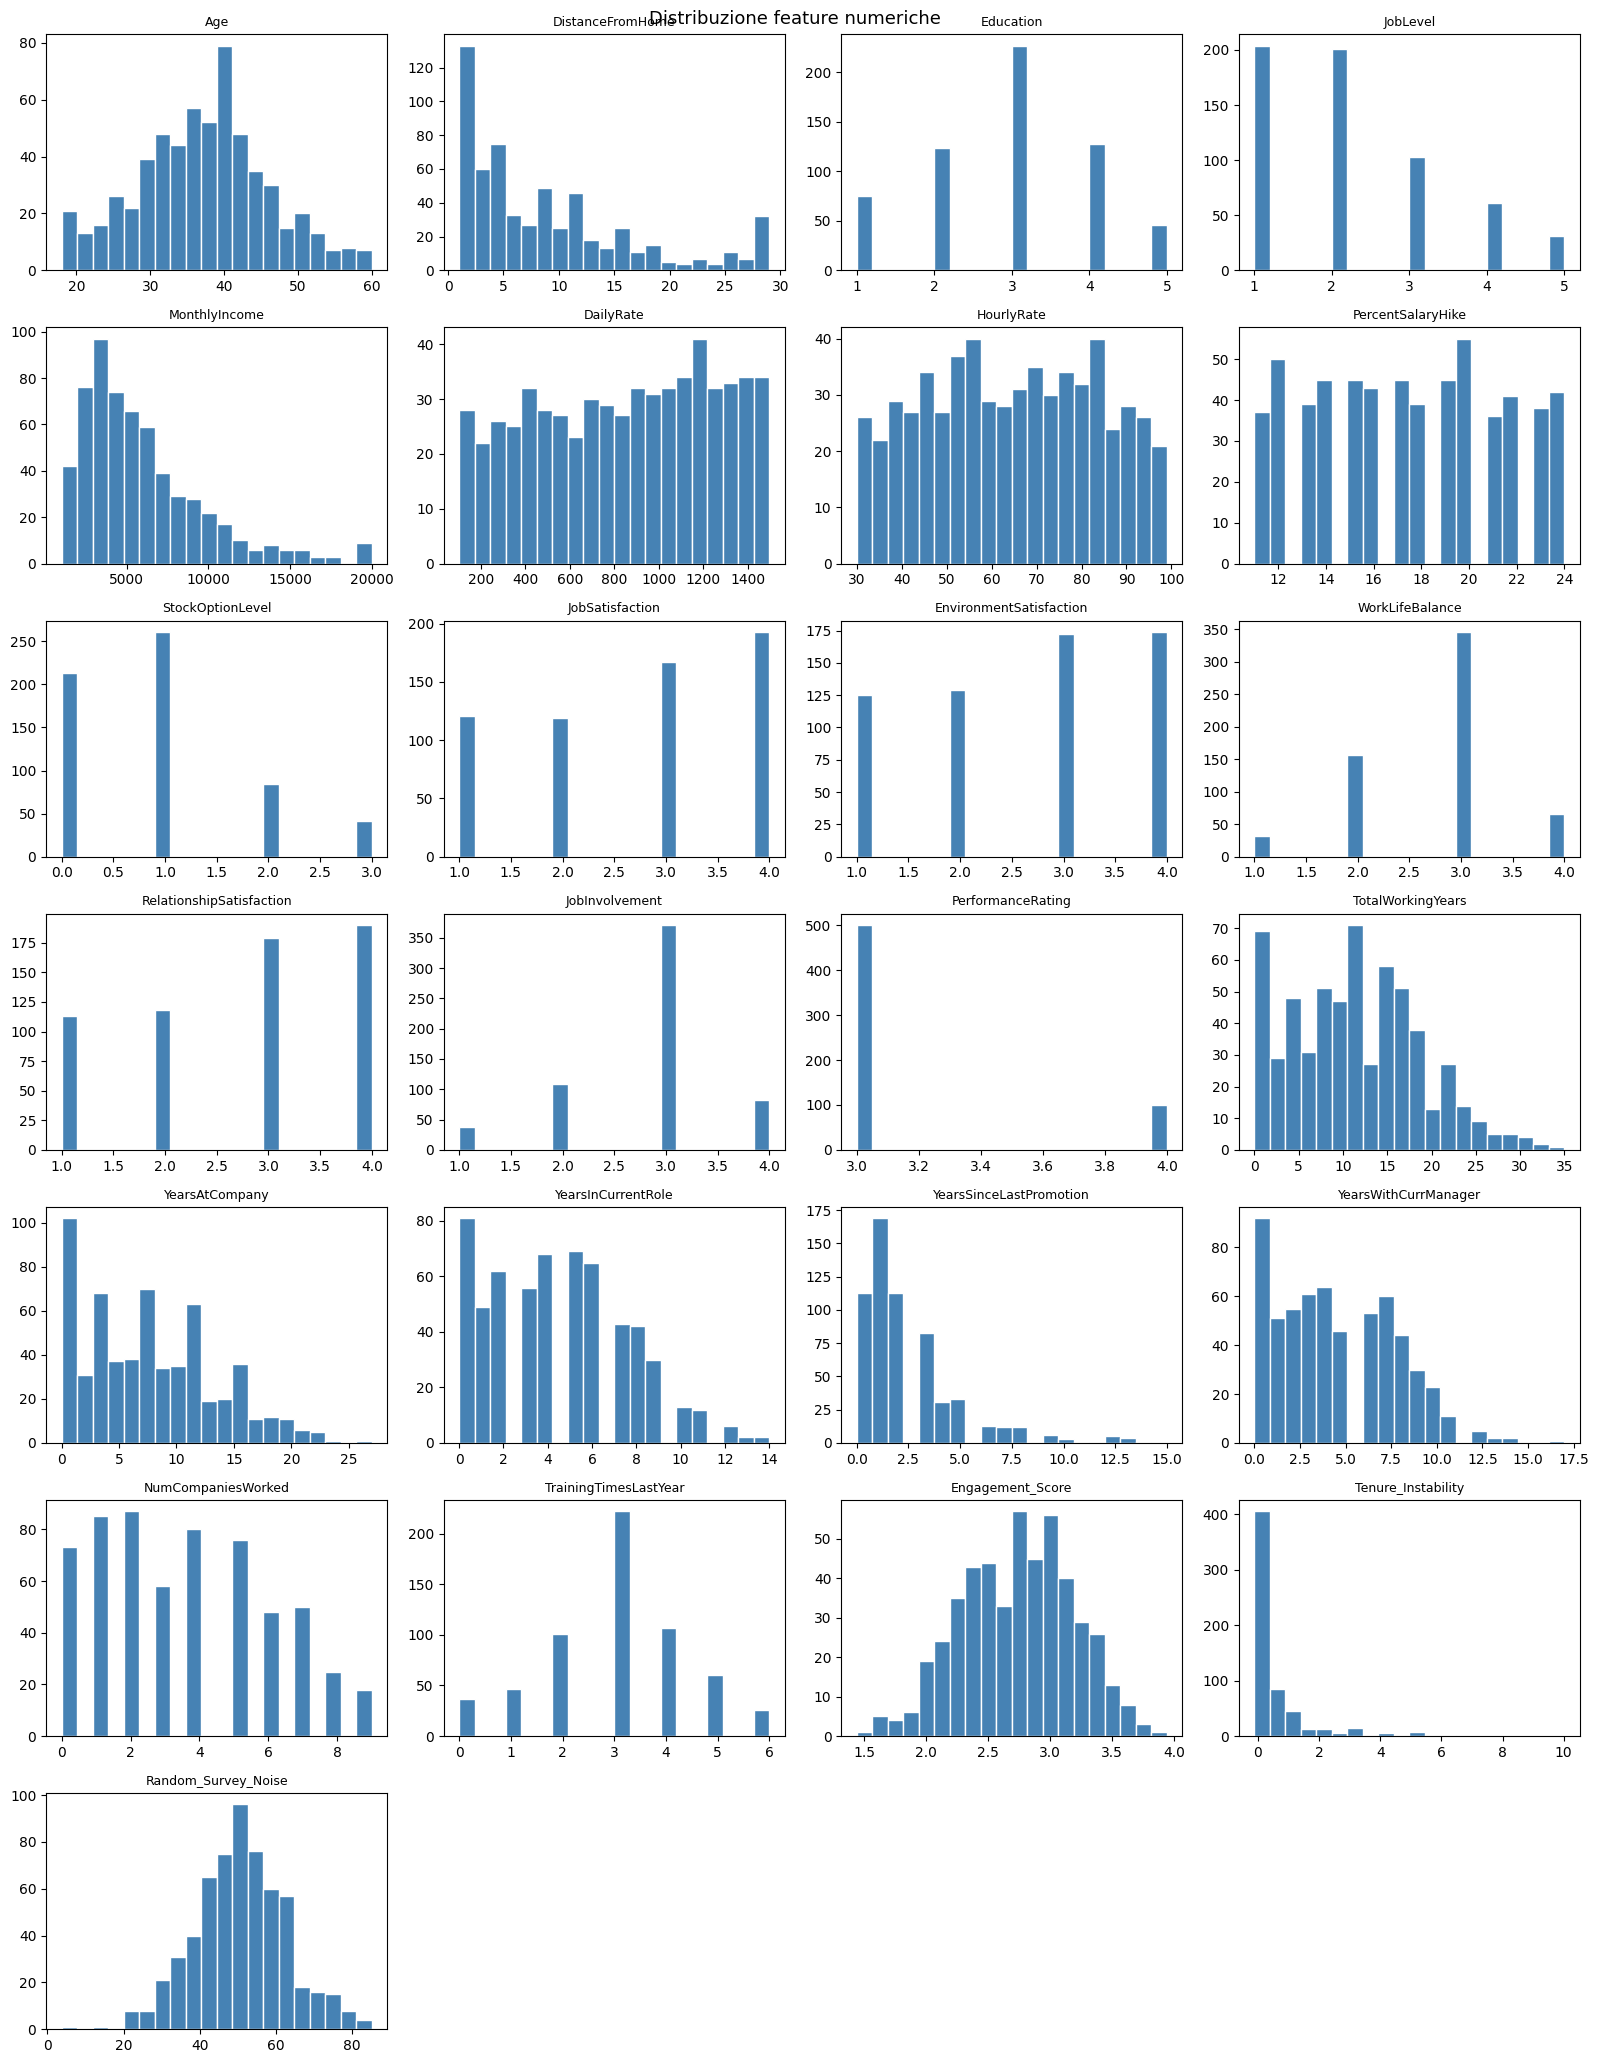

C:\Users\andre\AppData\Local\Temp\ipykernel_12500\570772204.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns.tolist()


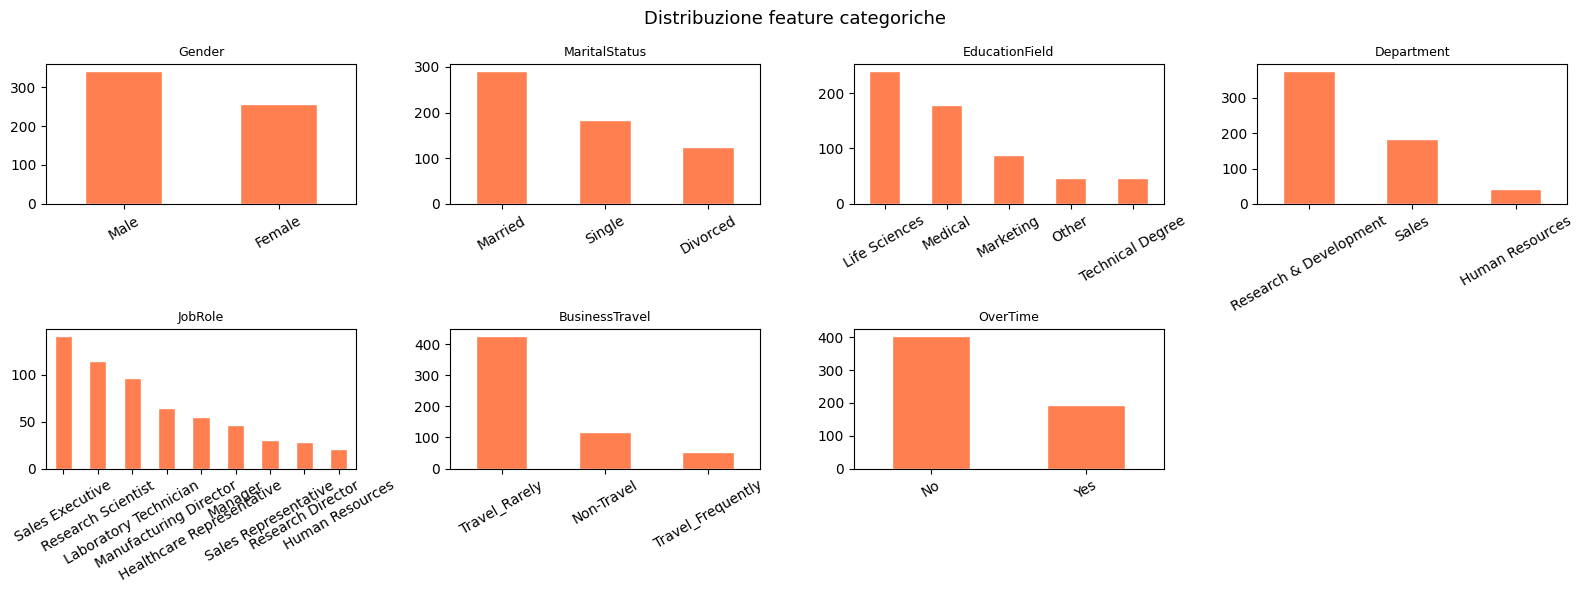

In [15]:
# --- Numerici: istogramma ---
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribuzione feature numeriche', fontsize=13)
plt.tight_layout()
plt.show()

# --- Categorici: countplot ---
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
n_rows_cat = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows_cat, n_cols, figsize=(16, n_rows_cat * 3))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribuzione feature categoriche', fontsize=13)
plt.tight_layout()
plt.show()

L’analisi grafica permette di distinguere chiaramente il comportamento delle variabili continue da quello delle variabili discrete/ordinali.
Per le variabili discrete e ordinali, i bar plot mostrano che alcune feature sono concentrate su pochi livelli dominanti. In particolare, `JobInvolvement` e `WorkLifeBalance` sono fortemente concentrate sul livello 3, mentre `PerformanceRating` presenta una variabilità molto limitata, con la maggior parte delle osservazioni sul valore 3. Questo suggerisce che alcune variabili potrebbero avere un potere descrittivo ridotto nell’analisi univariata, poiché distinguono poco tra i dipendenti.
Altre variabili, come `EnvironmentSatisfaction`, `JobSatisfaction` e `RelationshipSatisfaction`, risultano invece distribuite in modo più equilibrato tra i livelli, pur con una maggiore presenza di valori medio-alti. `StockOptionLevel` è concentrata soprattutto sui livelli 0 e 1, indicando che i livelli più alti di stock option sono meno frequenti nel dataset.
Per le variabili continue, gli istogrammi mostrano distribuzioni differenti. `Age` è concentrata principalmente tra 30 e 45 anni, mentre `DailyRate` e `HourlyRate` appaiono abbastanza distribuite lungo il loro intervallo. Al contrario, `MonthlyIncome`, `DistanceFromHome`, `TotalWorkingYears`, `YearsAtCompany`, `YearsSinceLastPromotion` e `YearsWithCurrManager` mostrano distribuzioni asimmetriche verso destra, con molti valori bassi o intermedi e pochi valori elevati.
Queste code verso destra non indicano necessariamente errori: in un dataset HR possono rappresentare profili realistici, come dipendenti senior, manager o persone con lunga permanenza in azienda. Per questo motivo, i valori estremi (outliers) individuati graficamente non vengono rimossi automaticamente, ma saranno analizzati successivamente tramite metodo IQR.

### 3.2 Distribuzione della Classe Target

Il dataset è **sbilanciato**: la maggior parte dei dipendenti non ha lasciato l'azienda. Questo impatta:
1) La scelta delle metriche di valutazione: l'accuracy da sola non è sufficiente, occorre guardare **Recall** e **F1-score** sulla classe minoritaria (Attrition = 1).
2) La scelta di effettuare una cross validation che tenga conto di questo sbilanciamento: verrà usata la StratifiedKFold

Distribuzione classi nel train set:
Attrition
0    507
1     93
Name: count, dtype: int64

Percentuale abbandono (classe 1): 15.5%


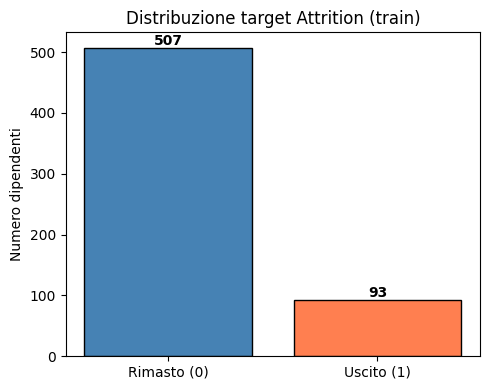

In [16]:
counts = train_with_label['Attrition'].value_counts().sort_index()
print('Distribuzione classi nel train set:')
print(counts)
print(f'\nPercentuale abbandono (classe 1): {counts[1] / len(train) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Rimasto (0)', 'Uscito (1)'], counts.values,
       color=['steelblue', 'coral'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Distribuzione target Attrition (train)')
ax.set_ylabel('Numero dipendenti')
plt.tight_layout()
plt.show()

## 4. Data preprocessing: gestione di Noise, outliers, Missing values, Duplicate data e Wrong Data

In [17]:
### funzioni utils per il data preprocessing  ###

def missing_summary(df):
    # Determina i missing values (con NaN) di un dataset
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        return None
    summary = pd.DataFrame({'n_missing': missing,'prop_missing': missing / df.shape[0],'dtype': df.dtypes[missing.index]
}).sort_values(by='prop_missing', ascending=False)
    return summary

def detect_outliers_iqr(df, cols):
    results = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (df[col] < lower) | (df[col] > upper)
        n = mask.sum()
        if n > 0:
            results[col] = { 'n_outliers': n, 'pct': round(n / len(df) * 100, 2), 'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2), 'min_value': df[col].min(), 'max_value': df[col].max()}
    return pd.DataFrame(results).T.sort_values('n_outliers', ascending=False)

def handle_missing_values_with_mean(df, col):
    df = df.copy()
    value = df[col].mean()
    df[col] = df[col].fillna(value)
    return df, value

def find_duplicate_rows(df):
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("Nessuna riga duplicata trovata.")
        return None
    print(f"Numero di righe duplicate: {duplicates.shape[0]}")
    return duplicates


def IQR(df):
    """
    Applica il metodo IQR a ogni colonna di continuous_df e restituisce
    un DataFrame riassuntivo con i bound, il numero di potenziali outlier
    e i loro valori per ogni variabile.
    Ritorna:  pd.DataFrame con una riga per variabile.
    """
    summary = []
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3-Q1
        upper_bound = Q3 + 1.5*IQR
        lower_bound = Q1 - 1.5*IQR
        sus = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
        summary.append({ 'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound, '# Possible Outliers': len(sus), '# Total Elements': len(df),
            'Possible Outliers': sus[col].tolist(), 'Possible Outliers (%)': round(len(sus[col])/len(df) * 100, 2)})
    return pd.DataFrame(summary)


def plot_histogram(df, column, bins=30):
    # Crea istogramma di una variabile column nel dataset
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non presente nel dataset.")
    if not (df[column].dtype in ['int64', 'float64']):
        raise TypeError(f"La colonna '{column}' non è numerica.")
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_histograms(df, columns, bins=20):
    n_cols = len(columns)
    n_rows = (n_cols + 2) // 3  
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
    axes = axes.flatten()  
    for i, col in enumerate(columns):
        axes[i].hist(df[col].dropna(), bins=bins)
        axes[i].set_title(col)
    
    # elimina assi vuoti
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()



### 4.1 Analisi e gestione del rumore (noise)
Osserviamo la presenza dell'attributo "RandomSurveyNoise" che rappresenta. E' quindi una colonna che indica la presenza di rumore non una feature informativa. Pertanto si è scelto di eliminarla dal dataset. 

In [18]:
train = train.drop(columns=['Random_Survey_Noise'])
train_with_label = train_with_label.drop(columns=['Random_Survey_Noise'])
test  = test.drop(columns=['Random_Survey_Noise'])

### 4.2 Analisi e gestione dei valori mancanti (missing values)
1) Individuazione
2) Gestione (attraverso sostituzione con media)

In [19]:
### Individuazione missing values

summary_train = missing_summary(train)
summary_test = missing_summary(test)

if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('Colonne con valori mancanti (test):')
    print(summary_test)

missing_cols_train = summary_train.index.tolist()




Colonne con valori mancanti (train):
                  n_missing  prop_missing    dtype
Engagement_Score        108          0.18  float64
Colonne con valori mancanti (test):
                  n_missing  prop_missing    dtype
Engagement_Score         27          0.18  float64


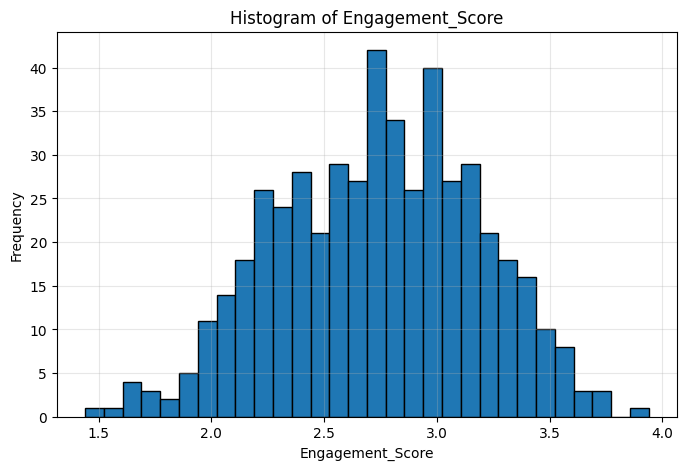

In [20]:
plot_histogram(train, missing_cols_train[0], bins=30)

Si nota una distribuzione abbastanza simmetrica e il campione è privo di outliers: si sceglie dunque di stimare i missing values tramite media campionaria.

L'unico attributo con missing values (sia nel train dataset che nel test dataset) è l"Engagement Score" che sappiamo essere di tipo continuo.
Si osserva il train dataset per comprendere quale approccio seguire con i missing values: la proporzione dei dati mancanti è sufficientemente considerevole dal non potere seguire la strategia dell'eliminazione delle osservazioni (righe del dataset) per una perdita di informazioni troppo alta. Allo stesso tempo non è così alta dall'eliminare completamente la variabile "Engagement Score" dalle variabili predittive. Quindi optiamo per una stima dei missing values e la sostituzione dei dati mancanti con tali stime. Tale approccio viene svolto anche sul test usando come stima quella presa dal train dataset.

In [21]:
train, mean = handle_missing_values_with_mean(train, col=missing_cols_train[0])
train[missing_cols_train[0]] = train[missing_cols_train[0]].fillna(mean)
train_with_label[missing_cols_train[0]] = train_with_label[missing_cols_train[0]].fillna(mean)
test[missing_cols_train[0]] = test[missing_cols_train[0]].fillna(mean)

# Check
summary_train = missing_summary(train)
if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

summary_test = missing_summary(test)
if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('Colonne con valori mancanti (test):')
    print(summary_test)

Nessun valore mancante nel train set.
Nessun valore mancante nel test set.


### 4.3 Analisi e gestione dei dati duplicati
Non ci sono data object duplicati

In [22]:
dup_train = find_duplicate_rows(train_with_label)

Nessuna riga duplicata trovata.


### 4.4 Analisi e gestione outliers
Affronteremo l'analisi degli outliers sotto tre diverse prospettive: approccio univariato usando metodo IQR, approccio bivariato usando la distanza di Mahalanobis e l'approccio multivariato di tipo clustering dove verrà usato 
il metodo DBSCAN.

#### 4.4.1 Univariate Outlier analysis tramite metodo IQR

Viene applicato il metodo IQR alle variabili numeriche ***continue*** per individuare potenziali valori anomali.
Non viene considerata l'analisi per variabili numeriche discrete come JobSatisfaction, Education, WorkLifeBalance ecc. — queste hanno un range fisso e ristretto.
Il metodo IQR utilizza il primo quartile, il terzo quartile e l’intervallo interquartile per definire due soglie:

Lower Bound = Q1 - 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

I valori al di sotto della soglia inferiore o al di sopra della soglia superiore vengono identificati come potenziali outlier. Tuttavia, in questa fase non vengono rimossi automaticamente: vengono solo segnalati per una successiva interpretazione. Infatti, ad esempio, in un dataset HR, valori elevati di variabili come MonthlyIncome, TotalWorkingYears o YearsAtCompany possono rappresentare profili reali di dipendenti senior, non necessariamente errori. Similmente, un numero elevato di anni senza promozione può rappresentare una situazione aziendale reale e potenzialmente rilevante per l’analisi dell’attrition. 

In [23]:
# Selezioniamo solo le variabili numeriche (int e float) dal train set, escludendo le variabili ordinali a range ristretto (es. JobSatisfaction 1-4)
numeric_cols = train.select_dtypes(include=['int64', 'float64'])
continuous_cols = numeric_cols[[col for col in numeric_cols.columns if col not in discrete_features]]

# Applichiamo il metodo IQR a tutte le variabili continue. La funzione IQR() restituisce una riga per variabile con Q1, Q3, bounds e conteggio outlier.
iqr_results = IQR(continuous_cols)
# Teniamo solo le variabili per cui almeno un outlier è stato trovato
iqr_results = iqr_results[iqr_results['# Possible Outliers'] > 0]

# Per ogni osservazione del train, contiamo in quante variabili continue risulta outlier IQR.
n_variables_flagged_per_row = {row_idx: 0 for row_idx in train.index}
for _, iqr_row in iqr_results.iterrows():
    col = iqr_row['Variable']
    lower_bound = iqr_row['Lower Bound']
    upper_bound = iqr_row['Upper Bound']
    # osservazioni che che escono dai bound per questa variabile specifica
    flagged_rows = continuous_cols[(continuous_cols[col] < lower_bound) | (continuous_cols[col] > upper_bound)].index
    for row_idx in flagged_rows:
        n_variables_flagged_per_row[row_idx] += 1
univariate_outlier_count = [n_variables_flagged_per_row[row_idx] for row_idx in train.index]

# Una riga è un outlier univariato se è fuori dai bound in almeno una variabile
is_univariate_outlier = [count > 0 for count in univariate_outlier_count]
n_univariate_outlier_rows = sum(is_univariate_outlier)

# Distribuzione: quante osservazioni sono outlier in esattamente 0, 1, 2, ... variabili. # Es. {0: 520, 1: 45, 2: 23} → 45 righe sono outlier in 1 sola variabile, ecc.
distribution_by_n_variables = {}
for count in univariate_outlier_count:
    distribution_by_n_variables[count] = distribution_by_n_variables.get(count, 0) + 1

In [24]:
print("Variabili con outliers (secondo metodo IQR) univariati:")
print(iqr_results[['Variable', '# Possible Outliers']])
print()
print(f'Data object con almeno un outlier univariato: {n_univariate_outlier_rows}')
print(f'Percentuale sul train: {n_univariate_outlier_rows / len(train) * 100:.1f}%')
print(f'(N, numero di osservazioni che sono outliers in un numero di attributi pari a N): {dict(sorted(distribution_by_n_variables.items()))}')


Variabili con outliers (secondo metodo IQR) univariati:
                   Variable  # Possible Outliers
1          DistanceFromHome                   27
2             MonthlyIncome                   27
6         TotalWorkingYears                    3
7            YearsAtCompany                    2
8        YearsInCurrentRole                    4
9   YearsSinceLastPromotion                   45
10     YearsWithCurrManager                    1
13         Engagement_Score                   11
14       Tenure_Instability                   68

Data object con almeno un outlier univariato: 156
Percentuale sul train: 26.0%
(N, numero di osservazioni che sono outliers in un numero di attributi pari a N): {0: 444, 1: 126, 2: 28, 3: 2}


Il metodo IQR ha individuato potenziali outlier in diverse variabili continue. Sono diverse le variabili con almeno un sospetto outliers tra cui DistanceFromHome, MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, Engagement_Score. Si procede con le analisi bivariate e multivariate.

### 4.4.2 Analisi bivariata degli outlier

Dopo aver individuato i potenziali outlier tramite il metodo IQR, l’analisi prosegue con una fase bivariata. Allo stesso modo dell'analisi univariata l’obiettivo non è eliminare automaticamente i valori estremi, ma individuare quali possano essere gli outliers se si considera una coppia di attributi. Dopo l'analisi bivariata si procede con l'analisi multivariata. 
L'analisi bivariata viene svolta tramite definizione della distribuzione empirica congiunta dei due attributi e utilizzo della distanza di Mahalanobis per discriminare gli outliers nel metodo bivariato.
L'analisi bivariata viene svolta solo su quelle coppie di attributi che potrebbero avere una possibile dipendenza (per esempio correlazione) in cui quindi la distribuzione congiunta dei due attributi può supportare informazioni ulteriori rispetto all'analisi univariata. Per esempio la variabile "DistanceFromHome" difficilmente possiede una dipendenza con le altre variabili. 
Per scegliere queste coppie si usano quindi due criteri:
1) Basato su variabili altamente correlate. Per esempio - vedi Heatmap della correlazione nella sezione ... della feauture selection - EngagementScore e JobSatisfaction sono altamente correlati
2) Variabili che potrebbero avere una dipendenza visto il loro significato. Per esempio potrebbe sussistere una dipendenza tra MonthlyIncome e JobLevel o TotalWorkingYears: un reddito alto è plausibile se associato a un livello lavorativo elevato, a ruoli più senior o a molti anni di esperienza.

Ecco le coppie scelte per l'analisi bivariata:

In [25]:
coppie_scelte = [
    # --- Gruppo 1: Carriera e anzianità ---
    ('TotalWorkingYears',       'Age'),
    ('YearsAtCompany',          'TotalWorkingYears'),
    ('YearsInCurrentRole',      'YearsAtCompany'),
    ('YearsSinceLastPromotion', 'YearsAtCompany'),
    ('YearsWithCurrManager',    'YearsAtCompany'),

    # --- Gruppo 2: Compensazione e seniority ---
    ('MonthlyIncome',    'JobLevel'),
    ('MonthlyIncome',    'TotalWorkingYears'),
    ('MonthlyIncome',    'Age'),
    ('PercentSalaryHike','PerformanceRating'),

    # --- Gruppo 3: Instabilità di carriera ---
    ('Tenure_Instability', 'YearsSinceLastPromotion'),
    ('Tenure_Instability', 'YearsAtCompany'),
    ('Tenure_Instability', 'YearsInCurrentRole'),    
    ('NumCompaniesWorked', 'TotalWorkingYears'),
    ('NumCompaniesWorked', 'Age'),

    # --- Gruppo 4: Anni aziendali incrociati ---
    ('YearsSinceLastPromotion', 'YearsInCurrentRole'),
    ('YearsWithCurrManager',    'YearsInCurrentRole'),
    ('YearsWithCurrManager',    'YearsSinceLastPromotion'),

    # --- Gruppo 5: Engagement e soddisfazione ---
    ('Engagement_Score', 'JobSatisfaction'),
    ('Engagement_Score', 'EnvironmentSatisfaction'),
    ('Engagement_Score', 'WorkLifeBalance'),         
    ('Engagement_Score', 'RelationshipSatisfaction'), 
]

In [26]:
def _compute_mahalanobis_distances(data_matrix, mean_vector, inverse_cov_matrix):
    """Calcola le distanze di Mahalanobis al quadrato per ogni osservazione."""
    diff = data_matrix - mean_vector
    return np.einsum('ij,jk,ik->i', diff, inverse_cov_matrix, diff)

def compute_mahalanobis_outliers(df, col_a, col_b, alpha=0.975):
    """
    Individua outlier bivariati tra col_a e col_b tramite distanza di Mahalanobis.
    Una osservazione è outlier se la sua distanza supera il quantile chi² a 2 gradi
    di libertà con livello alpha.
    """
    pair_data = df[[col_a, col_b]].dropna()

    # Saltiamo la coppia se una variabile è costante
    if pair_data[col_a].std() < 1e-10 or pair_data[col_b].std() < 1e-10:
        return None, None, None, None
    if not np.isfinite(pair_data.values).all():
        return None, None, None, None
    data_matrix = pair_data.to_numpy()
    cov_matrix   = np.cov(data_matrix, rowvar=False)
    inverse_cov_matrix = np.linalg.pinv(cov_matrix)
    chi2_threshold  = chi2.ppf(alpha, df=2)
    pair_data = pair_data.copy()
    pair_data['mahalanobis_sq'] = _compute_mahalanobis_distances( data_matrix, data_matrix.mean(axis=0), inverse_cov_matrix)
    pair_data['is_outlier'] = pair_data['mahalanobis_sq'] > chi2_threshold
    n_outliers = pair_data['is_outlier'].sum()
    pct_outliers = round(n_outliers / len(pair_data) * 100, 2)

    return pair_data, chi2_threshold, n_outliers, pct_outliers

In [27]:
# Selezioniamo le colonne numeriche su cui applicare la Mahalanobis
numeric_train = train.select_dtypes(include=['int64', 'float64'])

# Individuazione degli outliers per ogni coppia di attributi scelta
print("Attributi con outliers e percentuali di outliers:")
print()
mahal_results = {}
for col_a, col_b in coppie_scelte:
    pair_data, _, n_outliers, pct_outliers = compute_mahalanobis_outliers(numeric_train, col_a, col_b)
    if pair_data is None:
        continue
    mahal_results[(col_a, col_b)] = {'data': pair_data, 'n_outliers': n_outliers, 'pct': pct_outliers}
    print(f'{col_a} vs {col_b}: {n_outliers} outlier ({pct_outliers}%)')


Attributi con outliers e percentuali di outliers:

TotalWorkingYears vs Age: 7 outlier (1.17%)
YearsAtCompany vs TotalWorkingYears: 7 outlier (1.17%)
YearsInCurrentRole vs YearsAtCompany: 9 outlier (1.5%)
YearsSinceLastPromotion vs YearsAtCompany: 22 outlier (3.67%)
YearsWithCurrManager vs YearsAtCompany: 10 outlier (1.67%)
MonthlyIncome vs JobLevel: 25 outlier (4.17%)
MonthlyIncome vs TotalWorkingYears: 26 outlier (4.33%)
MonthlyIncome vs Age: 21 outlier (3.5%)
PercentSalaryHike vs PerformanceRating: 11 outlier (1.83%)
Tenure_Instability vs YearsSinceLastPromotion: 36 outlier (6.0%)
Tenure_Instability vs YearsAtCompany: 22 outlier (3.67%)
Tenure_Instability vs YearsInCurrentRole: 25 outlier (4.17%)
NumCompaniesWorked vs TotalWorkingYears: 5 outlier (0.83%)
NumCompaniesWorked vs Age: 5 outlier (0.83%)
YearsSinceLastPromotion vs YearsInCurrentRole: 24 outlier (4.0%)
YearsWithCurrManager vs YearsInCurrentRole: 9 outlier (1.5%)
YearsWithCurrManager vs YearsSinceLastPromotion: 22 outlier (

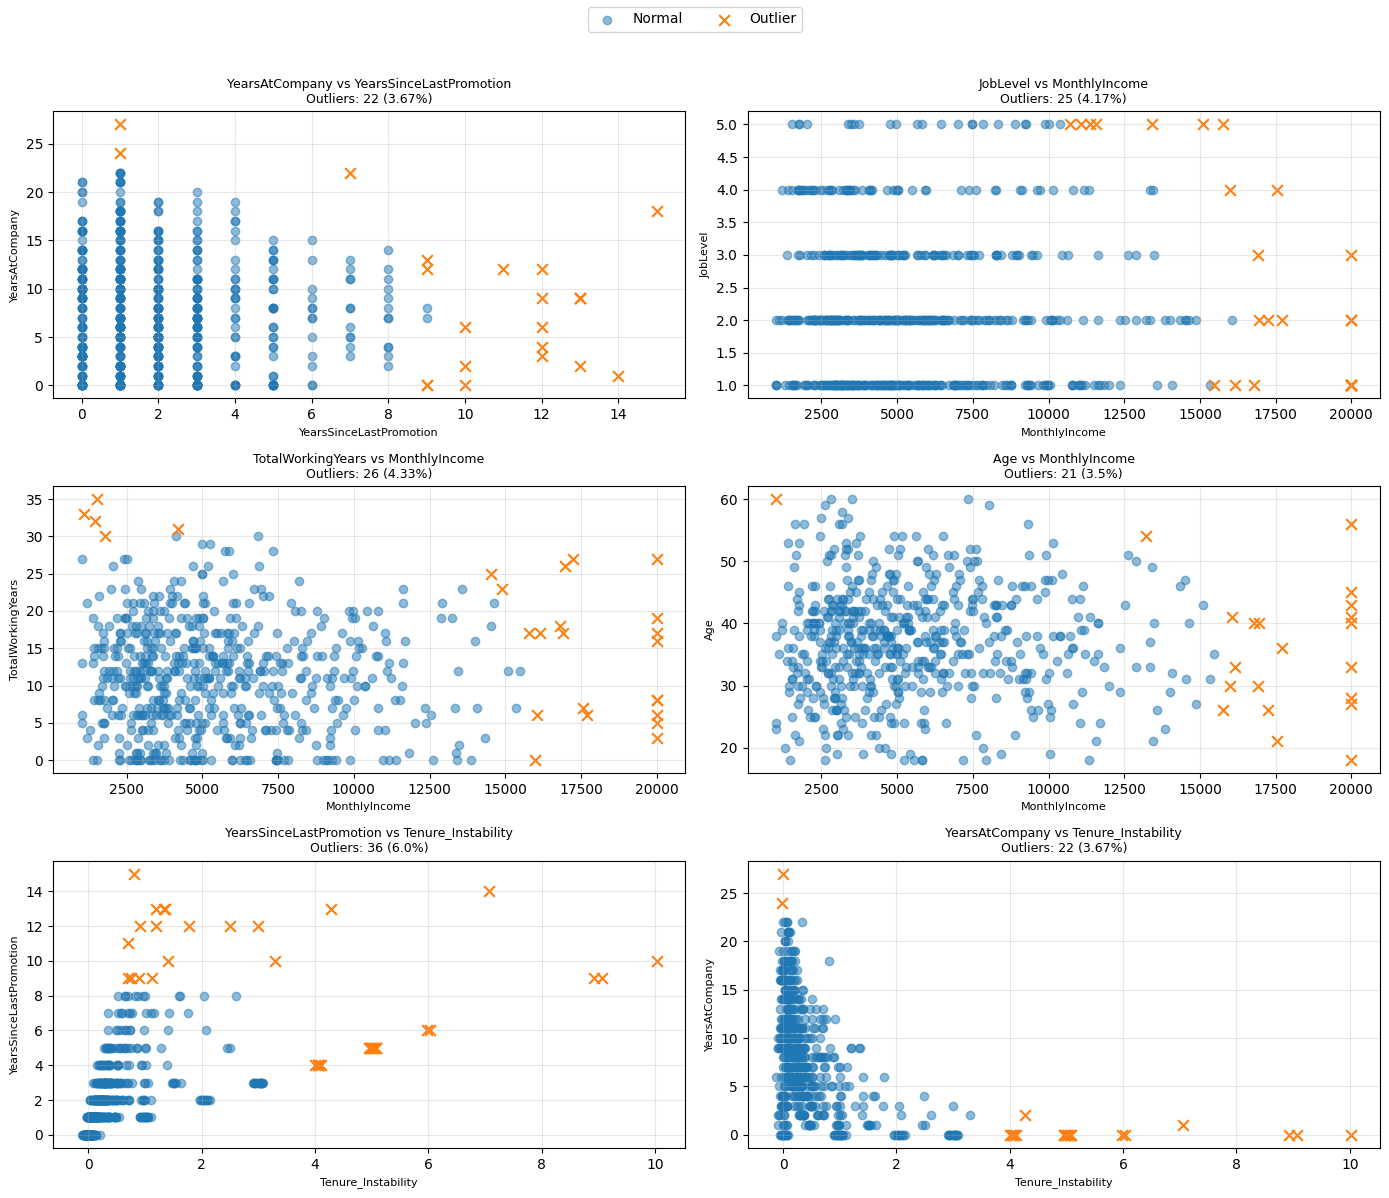

In [28]:
# Coppie da visualizzare
pairs_to_plot = [('MonthlyIncome', 'JobLevel'), ('MonthlyIncome', 'TotalWorkingYears'), ('YearsSinceLastPromotion', 'YearsAtCompany'),
    ('YearsSinceLastPromotion', 'Tenure_Instability'),('Tenure_Instability', 'YearsAtCompany'), ('MonthlyIncome', 'Age') ]

pairs_to_plot_set = {frozenset(pair) for pair in pairs_to_plot}

results_to_plot = {
    pair: res for pair, res in mahal_results.items()
    if not pairs_to_plot or frozenset(pair) in pairs_to_plot_set
}

n_cols = 2
n_rows = math.ceil(len(results_to_plot) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for ax, ((col_a, col_b), res) in zip(axes, results_to_plot.items()):
    pair_data = res['data']
    is_normal = ~pair_data['is_outlier']
    is_outlier = pair_data['is_outlier']
    ax.scatter(pair_data.loc[is_normal,  col_a], pair_data.loc[is_normal,  col_b], alpha=0.5, label='Normal')
    ax.scatter(pair_data.loc[is_outlier, col_a], pair_data.loc[is_outlier, col_b], marker='x', s=60, label='Outlier')
    ax.set_title(f'{col_b} vs {col_a}\nOutliers: {res["n_outliers"]} ({res["pct"]}%)', fontsize=9)
    ax.set_xlabel(col_a, fontsize=8)
    ax.set_ylabel(col_b, fontsize=8)
    ax.grid(alpha=0.3)

# Nascondiamo gli assi vuoti se le coppie non riempiono tutta la griglia
for j in range(len(results_to_plot), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Outliers con metodo bivariato:

In [29]:
# Per ogni osservazione del train, contiamo in quante coppie risulta outlier bivariato
outlier_counts = {i: 0 for i in train.index}
for res in mahal_results.values():
    pair_data = res['data']
    for row_idx in pair_data[pair_data['is_outlier']].index:
        outlier_counts[row_idx] += 1

# Lista: 0 se non flaggato, n se flaggato in n coppie
bivariate_outlier_count = [outlier_counts[i] for i in train.index]
bivariate_outlier_mask  = [c > 0 for c in bivariate_outlier_count]
n_bivariate_outliers    = sum(bivariate_outlier_mask)

print(f'Coppie analizzate: {len(mahal_results)}')
print(f'Outlier bivariati unici: {n_bivariate_outliers}')
print(f'Percentuale sul train: {n_bivariate_outliers / len(train) * 100:.1f}%')
# Distribuzione: quante righe sono outlier in esattamente 0, 1, 2, ... coppie. Es. {0: 520, 1: 45, 2: 23} → 45 righe sono outlier in 1 sola coppia, ecc.
print(f'\nDistribuzione per numero di coppie: {dict(sorted({v: bivariate_outlier_count.count(v) for v in set(bivariate_outlier_count)}.items()))}')


Coppie analizzate: 21
Outlier bivariati unici: 115
Percentuale sul train: 19.2%

Distribuzione per numero di coppie: {0: 485, 1: 40, 2: 9, 3: 30, 4: 22, 5: 5, 6: 5, 7: 3, 9: 1}


#### 4.4.3 Analisi multivariata tramite DBSCAN
Viene utilizzato DBSCAN come metodo di clustering per l'individuazione di potenziali outlier multivariati.
DBSCAN è un algoritmo density-based: invece di richiedere un numero di cluster fissato a priori, identifica regioni dense di osservazioni e considera come noise i punti che non appartengono a nessuna regione sufficientemente densa. Questi punti vengono quindi interpretati come potenziali outlier multivariati.
A differenza di K-Means, che individua outlier tramite la distanza dal centroide del cluster, DBSCAN segnala osservazioni isolate rispetto alla densità locale dei dati. Esso è stato scelto in virtù della presenza di variabili categoriche in cui la distanza euclidea non si presta. In DBSCAN può essere superato questo limite tramite l'utilizzo della GowerDistance. Inoltre DBSCAN permette di individuare i "noise point", essi sono i papabili outliers visto che presenti in aree meno dense di osservazioni. 

In [30]:
dbscan_features = [col for col in train.columns]     # gestisce numeriche e categoriche
gower_matrix = gower.gower_matrix(train[dbscan_features].copy())

TypeError: Cannot interpret '<StringDtype(na_value=nan)>' as a data type

##### 4.4.3.1 Tuning iperparametri di DBSCAN
DBSCAN richiede due iperparametri: eps (raggio di vicinato) e min_samples (densità minima). Sceglierli a mano è difficile.
Inoltre il metodo classico per il tuning "knee heuristic" non produceva risultati (tutti i valori classificati come non noise e un unico cluster).
Quindi usiamo Optuna per esplorarli automaticamente. 
Optuna esegue N trial: in ogni trial suggerisce una combinazione di parametri,
esegue DBSCAN e valuta il risultato con uno score composito che bilancia
qualità del clustering (silhouette) e percentuale di outlier trovati (noise ratio). eps non viene cercato liberamente: viene prima stimato tramite k-distance knee heuristic
e poi Optuna lo fa variare nel ±50% di quel valore, restringendo lo spazio di ricerca.
Al termine dei trial viene selezionata la configurazione con lo score più alto.

In [ ]:
# UTILS per IPERPARAMETRI DBSCAN

# Stima di eps tramite knee sulla curva k-distance
# Per ogni punto calcola la distanza al k-esimo vicino, le ordina in modo
# crescente e cerca il "gomito" della curva: il punto in cui la distanza
# inizia a crescere bruscamente.
def estimate_knee_eps(distance_matrix, min_samples):
    distances, _ = (NearestNeighbors(n_neighbors=min_samples, metric='precomputed').fit(distance_matrix).kneighbors(distance_matrix))
    k_distances = np.sort(distances[:, -1])
    knee = KneeLocator(range(len(k_distances)), k_distances,curve='convex', direction='increasing')
    return k_distances[knee.knee] if knee.knee is not None else None


# Esegue DBSCAN e restituisce le metriche di valutazione
# Incapsula la chiamata a DBSCAN e raccoglie in un dict tutto ciò che serve
# sia per i filtri di Optuna (n_clusters, noise_ratio).
def run_dbscan(distance_matrix, eps, min_samples):
    labels = DBSCAN(eps=eps, min_samples=min_samples,metric='precomputed').fit_predict(distance_matrix)
    n_clusters  = len(set(labels) - {-1})
    n_noise = int((labels == -1).sum())
    noise_ratio = n_noise / len(labels)
    # Silhouette
    non_noise = labels != -1
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(distance_matrix[non_noise][:, non_noise],labels[non_noise], metric='precomputed')
    else:
        sil = 0.0   # con 1 solo cluster la silhouette non è definita
    return {"labels": labels, "n_clusters": n_clusters, "n_noise": n_noise, "noise_ratio": noise_ratio, "silhouette": sil}


# Score composto da due metriche per Optuna 
# Combina qualità del clustering (silhouette) e quantità di noise.
# La penalità sul noise è logaritmica rispetto al target del 5%:
def composite_score(silhouette, noise_ratio):
    noise_penalty = -abs(np.log10(noise_ratio / 0.05)) if noise_ratio > 0 else -10
    return 0.6 * silhouette + 0.4 * max(noise_penalty, -2)

#  Funzione obiettivo per Optuna
# Optuna chiama questa funzione ad ogni test. Stima eps dal knee e poi lo fa esplorare a
# Optuna nell'intorno ±50%.
def objective(trial):
    min_samples = trial.suggest_int("min_samples", 3, 30)
    knee_eps = estimate_knee_eps(gower_matrix, min_samples)
    if not knee_eps:
        trial.set_user_attr("reject_reason", "no_knee")
        return float("-inf")
    eps = trial.suggest_float("eps", knee_eps * 0.5, knee_eps * 1.5)
    trial.set_user_attr("knee_eps", round(float(knee_eps), 4))
    m = run_dbscan(gower_matrix, eps, min_samples)
    for key in ["n_clusters", "n_noise", "silhouette"]:
        trial.set_user_attr(key, m[key])
    trial.set_user_attr("eps", round(float(eps), 4))
    trial.set_user_attr("noise_ratio", round(float(m["noise_ratio"]), 4))
    if m["n_clusters"] < 1:
        trial.set_user_attr("reject_reason", "no_cluster"); return float("-inf")
    if m["noise_ratio"] == 0:
        trial.set_user_attr("reject_reason", "no_noise"); return float("-inf")
    if m["noise_ratio"] > 0.50:
        trial.set_user_attr("reject_reason", "too_much_noise"); return float("-inf")
    trial.set_user_attr("reject_reason", "valid")
    return composite_score(m["silhouette"], m["noise_ratio"])


In [ ]:
# Ottimizzazione iperparametri tramite optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300)



[I 2026-05-24 20:58:16,410] A new study created in memory with name: no-name-fc726998-56a4-4019-9a69-a30daff6e2de
[I 2026-05-24 20:58:16,462] Trial 0 finished with value: -inf and parameters: {'min_samples': 10, 'eps': 0.3653074820373792}. Best is trial 0 with value: -inf.
[I 2026-05-24 20:58:16,480] Trial 1 finished with value: -inf and parameters: {'min_samples': 3, 'eps': 0.2967699695641292}. Best is trial 0 with value: -inf.
[I 2026-05-24 20:58:16,505] Trial 2 finished with value: -0.22090500918621891 and parameters: {'min_samples': 4, 'eps': 0.21572429008888044}. Best is trial 2 with value: -0.22090500918621891.
[I 2026-05-24 20:58:16,522] Trial 3 finished with value: -0.005696175645844077 and parameters: {'min_samples': 14, 'eps': 0.23917539058906784}. Best is trial 3 with value: -0.005696175645844077.
[I 2026-05-24 20:58:16,541] Trial 4 finished with value: -inf and parameters: {'min_samples': 22, 'eps': 0.3812372120037538}. Best is trial 3 with value: -0.005696175645844077.
[I 

In [ ]:
# Estrazione migliori iperparametri (esp e min_samples)
best_trial = study.best_trial
best_min_samples = best_trial.params["min_samples"]
best_eps = best_trial.params["eps"]

print("Best DBSCAN configuration")
print(f"eps: {round(best_eps, 4)}")
print(f"min_samples: {best_min_samples}")
print(f"score: {round(best_trial.value, 4)}")
print(f"n_clusters: {best_trial.user_attrs['n_clusters']}")
print(f"n_noise: {best_trial.user_attrs['n_noise']}")
print(f"noise_ratio: {best_trial.user_attrs['noise_ratio']}")
print(f"silhouette: {best_trial.user_attrs['silhouette']}")
print(f"knee_eps: {best_trial.user_attrs.get('knee_eps', 'N/A')}")

Best DBSCAN configuration
eps: 0.2363
min_samples: 7
score: 0.0
n_clusters: 1
n_noise: 30
noise_ratio: 0.05
silhouette: 0.0
knee_eps: 0.2736


##### 4.4.3.2 DBSCAN sul dataset
Si applica la tecnica di clustering DBSCAN sul dataset.

In [ ]:
# Applicazione di DBSCAN con i parametri ottimali trovati da Optuna
dbscan_final  = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric="precomputed")
dbscan_labels = dbscan_final.fit_predict(gower_matrix)

# Le osservazioni con label == -1 sono i punti "noise" — potenziali outlier multivariati
dbscan_outlier_mask  = [label == -1 for label in dbscan_labels]
dbscan_outlier_count = [1 if x else 0 for x in dbscan_outlier_mask]
n_dbscan_outliers = sum(dbscan_outlier_mask)

In [ ]:
print(f'DBSCAN cluster distribution:\n{pd.Series(dbscan_labels).value_counts().sort_index()}')
print(f'\nOutlier multivariati (noise): {n_dbscan_outliers}')
print(f'Percentuale sul train: {n_dbscan_outliers / len(train) * 100:.1f}%')

DBSCAN cluster distribution:
-1     30
 0    570
Name: count, dtype: int64

Outlier multivariati (noise): 30
Percentuale sul train: 5.0%


DBSCAN ha identificato 30 osservazioni come noise (5% del train), assegnandole a un unico cluster denso le restanti 570. Le 30 osservazioni noise sono i potenziali outlier multivariati che verranno confrontati con i risultati dei metodi univariato e bivariato nel blocco successivo.

### 4.4.2 Aggregazione dei risultati: univariato, bivariato e multivariato
I tre metodi applicati (IQR univariato, Mahalanobis bivariato, DBSCAN multivariato) segnalano outlier
da prospettive diverse: i metodi univariati e bivariati analizzano le variabili singolarmente o a coppie,
mentre DBSCAN considera l'osservazione nella sua totalità tenendo conto dell'interdipendenza tra tutte le variabili.
In linea di principio l'approccio multivariato sarebbe il più appropriato, tuttavia su dataset di dimensioni
ridotte come il nostro perde affidabilità: al crescere della dimensionalità il numero di osservazioni
necessarie per stimare correttamente la struttura di densità cresce esponenzialmente (curse of dimensionality).
Per questo motivo integriamo i risultati dei tre metodi: un'osservazione flaggata da più approcci
è più credibilmente anomala rispetto a una segnalata da uno solo.
I due plot seguenti mostrano questa integrazione da due angolazioni complementari:
1. Partendo dagli outlier DBSCAN, verifichiamo quanti erano già stati segnalati anche da IQR e Mahalanobis.
2. Partendo dal top 5% degli outlier bivariati, verifichiamo quali non sono emersi in DBSCAN ma sono stati segnalati ripetutamente nelle analisi precedenti.

1. Outliers provenienti da DBSCAN

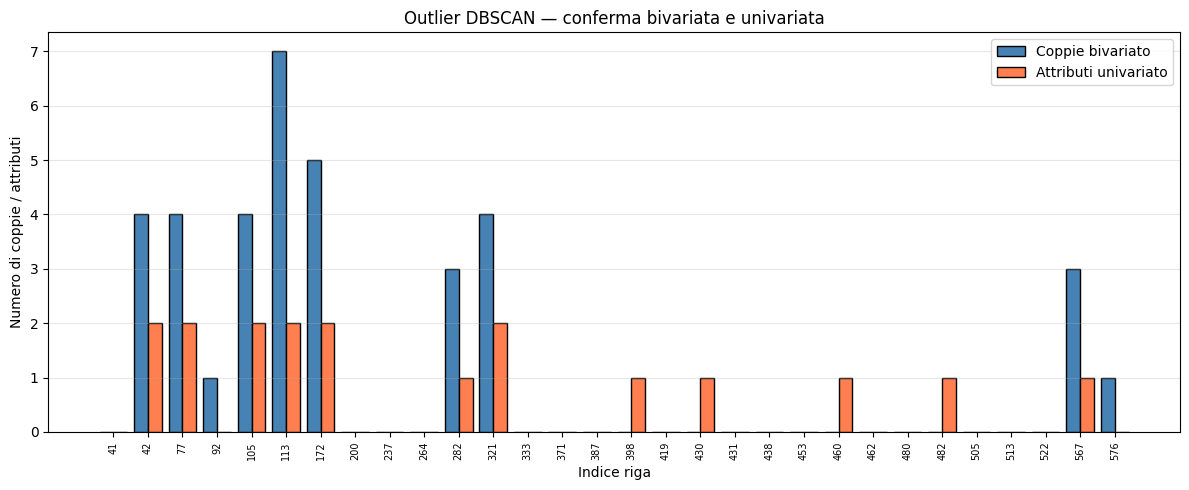

In [ ]:
# Plot 1: per ogni outlier DBSCAN, mostriamo quante volte era stato flaggato
# anche da metodo univariato IQR (barre corallo) e metodo bivariato Mahalanobis (barre blu)

dbscan_outlier_idx = [i for i, x in enumerate(dbscan_outlier_mask) if x]
# Per ognuno prendi il conteggio bivariato e univariato
biv_counts_dbscan = [bivariate_outlier_count[i] for i in dbscan_outlier_idx]
uni_counts_dbscan = [univariate_outlier_count[i] for i in dbscan_outlier_idx]
x = np.arange(len(dbscan_outlier_idx))
width= 0.4

fig, ax = plt.subplots(figsize=(max(10, len(dbscan_outlier_idx) * 0.4), 5))
ax.bar(x - width/2, biv_counts_dbscan, width, label='Coppie bivariato', color='steelblue', edgecolor='black')
ax.bar(x + width/2, uni_counts_dbscan, width, label='Attributi univariato', color='coral', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([str(train.index[i]) for i in dbscan_outlier_idx], rotation=90, fontsize=7)
ax.set_xlabel('Indice riga')
ax.set_ylabel('Numero di coppie / attributi')
ax.set_title('Outlier DBSCAN — conferma bivariata e univariata')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


2. Outliers provenienti da metodo bivariato

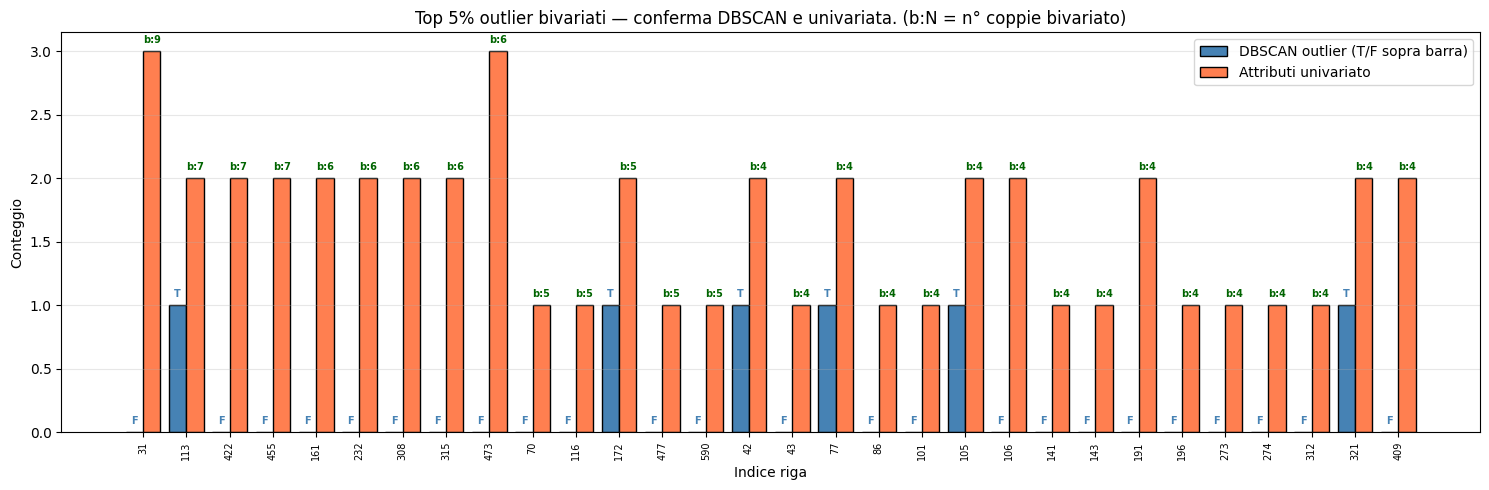

In [ ]:
# Plot 2: partiamo dal top 5% delle osservazioni più flaggate dal metodo bivariato
# e verifichiamo se DBSCAN le conferma (T/F sopra le barre blu) e quante
# variabili IQR le avevano già segnalate (barre corallo, etichetta b:N)

threshold_out = 0.05
n_top = max(1, int(len(train) * threshold_out))
biv_series  = pd.Series(bivariate_outlier_count, index=train.index)
top_biv_idx = biv_series.nlargest(n_top).index.tolist()
dbscan_vals = [dbscan_outlier_count[i] for i in top_biv_idx]
uni_vals = [univariate_outlier_count[i] for i in top_biv_idx]
biv_vals = [bivariate_outlier_count[i] for i in top_biv_idx]
x = np.arange(len(top_biv_idx))
width = 0.4
fig, ax = plt.subplots(figsize=(max(10, len(top_biv_idx) * 0.5), 5))
bars_dbscan = ax.bar(x - width/2, dbscan_vals, width, color='steelblue', edgecolor='black', label='DBSCAN outlier (T/F sopra barra)')
bars_uni    = ax.bar(x + width/2, uni_vals,    width, color='coral',     edgecolor='black', label='Attributi univariato')
for bar, val in zip(bars_dbscan, dbscan_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, 'T' if val == 1 else 'F', ha='center', va='bottom', fontsize=7, color='steelblue', fontweight='bold')
for bar, biv in zip(bars_uni, biv_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f'b:{biv}', ha='center', va='bottom', fontsize=7, color='darkgreen', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in top_biv_idx], rotation=90, fontsize=7)
ax.set_xlabel('Indice riga')
ax.set_ylabel('Conteggio')
ax.set_title(f'Top {int(threshold_out*100)}% outlier bivariati — conferma DBSCAN e univariata. (b:N = n° coppie bivariato)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Due osservazioni:
- percentuale outliers bivariati nel dataset: 19.2%
- percentuale outliers bivariati tra gli outliers multivariati: 33%
quindi dai un pò di coerenza c'è 

Manca quindi effettuare scelta finale delle osservazioni:
possibile regola: di quelli multivariati si prendono quelli in cui c'è almeno una univariata e bivariata anche 
di quelli bivariati non in multivariati si prendono quelli un cui ci sono un tot di bivariate

In [ ]:
# modificare train e train_with_label

### 4.5 Analisi e gestione dei wrong data
I wrong data sono quelle osservazioni che non rispettano il dominio rispettivo.
Considerando gli attributes values di ciascun attributo questi possiedono un range sensato (solitamente positivo): per esempio età va dai 18 ai 60 anni, la distanza va da 1.00 a 29.00, ecc. Questo è visibile nella prima tabella stampata. L'unico attributo con attribute values negativi è "Tenure_instability" che è l'indicatore del rapporto tra stagnazione nella carriera e anzianità aziendale (un valore basso indicherebbe una crescita regolare e coerente con gli anni). Esso non è necessariamente ristretto in dominio. Tali valori negativi inoltre, da analisi successive (svolte nella feature selection) si mostrano correlati con valori bassi di YearsSinceLastPromotion e YearsAtCompany avvalorando l'ipotesi che non siano wrong data.


In [ ]:
## Analisi e gestione dei wrong data — vincoli temporali ###

# Si definiscono 5 vincoli di plausibilità temporale e si rilevano le violazioni.

wrong_data_constraints = {
    'TotalWorkingYears > Age - 18':
        lambda df: df['TotalWorkingYears'] > (df['Age'] - 18),
    'YearsAtCompany > TotalWorkingYears':
        lambda df: df['YearsAtCompany'] > df['TotalWorkingYears'],
    'YearsInCurrentRole > YearsAtCompany':
        lambda df: df['YearsInCurrentRole'] > df['YearsAtCompany'],
    'YearsSinceLastPromotion > YearsAtCompany':
        lambda df: df['YearsSinceLastPromotion'] > df['YearsAtCompany'],
    'YearsWithCurrManager > YearsAtCompany':
        lambda df: df['YearsWithCurrManager'] > df['YearsAtCompany'],
}

'''
wrong_data_constraints = {
    'YearsAtCompany > TotalWorkingYears':
        lambda df: df['YearsAtCompany'] > df['TotalWorkingYears'],
    'YearsInCurrentRole > YearsAtCompany':
        lambda df: df['YearsInCurrentRole'] > df['YearsAtCompany'],
    'YearsSinceLastPromotion > YearsAtCompany':
        lambda df: df['YearsSinceLastPromotion'] > df['YearsAtCompany'],
    'YearsWithCurrManager > YearsAtCompany':
        lambda df: df['YearsWithCurrManager'] > df['YearsAtCompany'],
}
'''

print('=== Rilevazione violazioni logiche (wrong data) ===\n')
any_violation = pd.Series(False, index=train_with_label.index)

report_rows = []
for constraint_name, check_fn in wrong_data_constraints.items():
    mask = check_fn(train_with_label)
    any_violation |= mask
    report_rows.append({
        'Vincolo violato': constraint_name,
        'N righe': mask.sum(),
        '% dataset': f'{mask.sum() / len(train_with_label) * 100:.1f}%'
    })

print(pd.DataFrame(report_rows).to_string(index=False))
print(f'\nRighe con almeno 1 violazione : {any_violation.sum()} '
      f'({any_violation.sum() / len(train_with_label) * 100:.1f}%)')
print(f'Righe completamente consistenti: {(~any_violation).sum()} '
      f'({(~any_violation).sum() / len(train_with_label) * 100:.1f}%)')

=== Rilevazione violazioni logiche (wrong data) ===

                         Vincolo violato  N righe % dataset
            TotalWorkingYears > Age - 18      152     25.3%
      YearsAtCompany > TotalWorkingYears      199     33.2%
     YearsInCurrentRole > YearsAtCompany      189     31.5%
YearsSinceLastPromotion > YearsAtCompany      109     18.2%
   YearsWithCurrManager > YearsAtCompany      181     30.2%

Righe con almeno 1 violazione : 499 (83.2%)
Righe completamente consistenti: 101 (16.8%)


In [ ]:

def apply_temporal_clipping(df):
    df = df.copy()
    # 1. Nessuno può avere più anni di carriera di (età - 18)
    df['TotalWorkingYears'] = df.apply(
        lambda r: min(r['TotalWorkingYears'], max(r['Age'] - 18, 0)), axis=1
    )
    # 2. Gli anni in azienda non possono superare la carriera totale
    df['YearsAtCompany'] = df[['YearsAtCompany', 'TotalWorkingYears']].min(axis=1)
    # 3. Gli anni nel ruolo attuale non possono superare gli anni in azienda
    df['YearsInCurrentRole'] = df[['YearsInCurrentRole', 'YearsAtCompany']].min(axis=1)
    # 4. Gli anni dall'ultima promozione non possono superare gli anni in azienda
    df['YearsSinceLastPromotion'] = df[['YearsSinceLastPromotion', 'YearsAtCompany']].min(axis=1)
    # 5. Gli anni con il manager attuale non possono superare gli anni in azienda
    df['YearsWithCurrManager'] = df[['YearsWithCurrManager', 'YearsAtCompany']].min(axis=1)
    return df

#train_with_label = apply_temporal_clipping(train_with_label)
#train = apply_temporal_clipping(train) 
#test = apply_temporal_clipping(test) 

# Verifica: nessuna violazione residua
print('\n=== Verifica post-clipping ===')
residue = 0
for constraint_name, check_fn in wrong_data_constraints.items():
    n = check_fn(train_with_label).sum()
    residue += n
    print(f'{constraint_name}: {n} violazioni residue')
print(f'\nViolazioni totali residue: {residue}  — {"OK" if residue == 0 else "ATTENZIONE"}')


=== Verifica post-clipping ===
TotalWorkingYears > Age - 18: 152 violazioni residue
YearsAtCompany > TotalWorkingYears: 199 violazioni residue
YearsInCurrentRole > YearsAtCompany: 189 violazioni residue
YearsSinceLastPromotion > YearsAtCompany: 109 violazioni residue
YearsWithCurrManager > YearsAtCompany: 181 violazioni residue

Violazioni totali residue: 830  — ATTENZIONE


# 5. Data preparation: Feature Selection, Feature Creation, Discretization, Encoding and Normalization

### 5.1 Feature Selection e Feature Creation
1) Si analizzano gli attributi e in particolare si identificano gli attributi rindondanti o poco informativi (in termini di task di classificazione di attrition)
Gli attributi rindondanti vengono identificati tramite due strumenti:
-> analisi correlazione: due attributi con alta correlazione in valore assoluto sono considerabili rindondanti
-> PCA: permetta di studiare le direzioni di massima varianza ovvero che massimizzano l'informazione all'interno dello spazio degli attributi 
Gli attributi poco informativi vengono identificati andando ad osservare come e se la label cambia al variare dello stesso.
2) Scelta e rimozione/creazione di attributi

#### 5.1.1 Correlazione tra feature numeriche

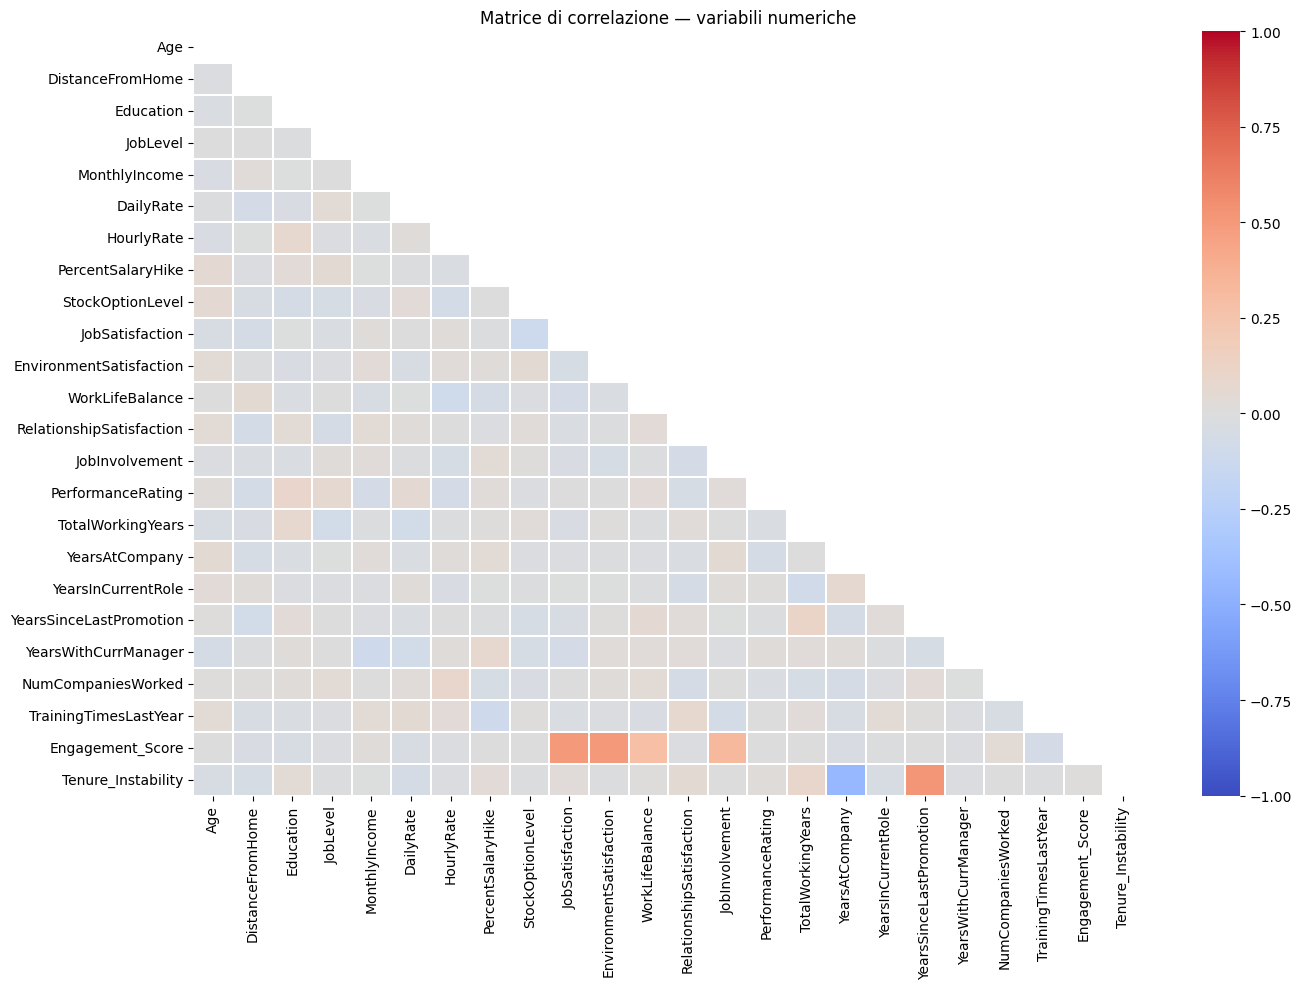

In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche')
plt.tight_layout()
plt.show()

A partire dalla heatmap rappresentante la matrice di correlazione andiamo a definire dei gruppi di attributi dove analizzare nel dettaglio la correlazione. 
Le variabili numeriche del dataset mostrano correlazioni generalmente basse, con due sole eccezioni rilevanti: 
1) Engagement score sembra correlare molto con Job Satisfaction e Environment Satisfaction
2) Si nota con evidenza l'alta correlazione positiva tra YearsSinceLastPromotion e TenureInstability e l'alta correlazione negativa tra YearsAtCompany e TenureInstability. 
Tali eccezioni saranno studiate di seguito.

1) Relazione tra Engagement score - Job Satisfaction e Environment Satisfaction

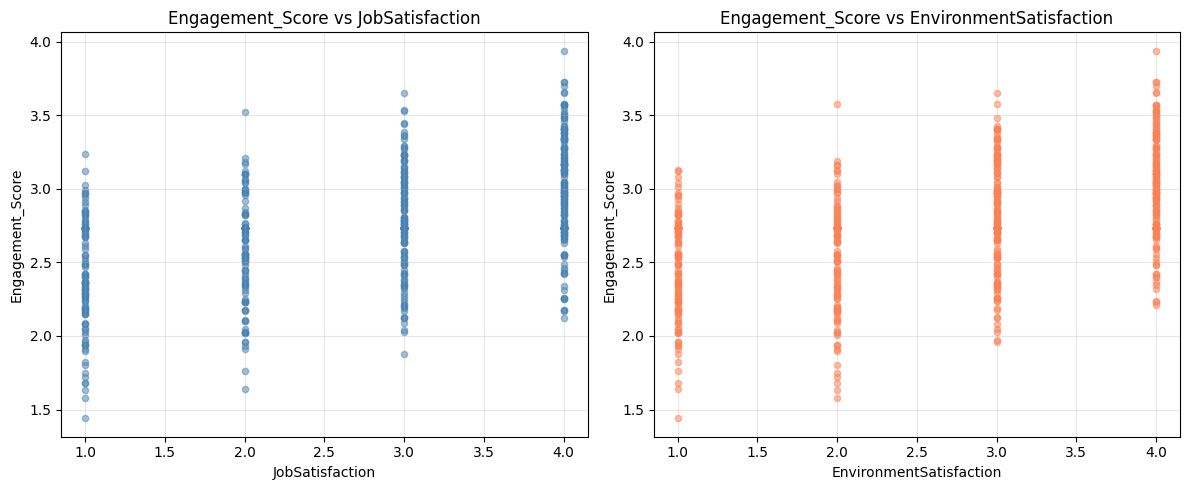

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(train["JobSatisfaction"], train_with_label["Engagement_Score"], alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel("JobSatisfaction")
axes[0].set_ylabel("Engagement_Score")
axes[0].set_title("Engagement_Score vs JobSatisfaction")
axes[0].grid(alpha=0.3)
axes[1].scatter(train["EnvironmentSatisfaction"], train_with_label["Engagement_Score"], alpha=0.5, s=20, color='coral')
axes[1].set_xlabel("EnvironmentSatisfaction")
axes[1].set_ylabel("Engagement_Score")
axes[1].set_title("Engagement_Score vs EnvironmentSatisfaction")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Si nota una possibile dipendenza lineare in entrambe le coppie di variabili. Si prova a testare una regressione lineare con variabili indipendenti JobSatisfaction ed EnvironmentSatisfaction e variabile dipendente EngagementScore.

In [ ]:
X = train[["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance", "JobInvolvement"]].values
y = train_with_label["Engagement_Score"].values
model = LinearRegression()
model.fit(X, y)
print(f"β0 (intercetta):          {model.intercept_:.4f}")
print(f"β1 (JobSatisfaction):     {model.coef_[0]:.4f}")
print(f"β2 (EnvironmentSat):      {model.coef_[1]:.4f}")
print(f"β3 (WorkLifeBalance):     {model.coef_[2]:.4f}")
print(f"β4 (JobInvolvement.):     {model.coef_[3]:.4f}")
print(f"R²:                       {model.score(X, y):.4f}")
mu_pred = model.predict(X)
sigma = np.sqrt(np.mean((y - mu_pred) ** 2))
print(f"Sigma stimato: {sigma:.4f}")

β0 (intercetta):          0.5463
β1 (JobSatisfaction):     0.2027
β2 (EnvironmentSat):      0.2015
β3 (WorkLifeBalance):     0.1898
β4 (JobInvolvement.):     0.2054
R²:                       0.7673
Sigma stimato: 0.1951


Il modello con intercetta e 4 feature (JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, JobInvolvement)
raggiunge R² = 0.77, spiegando circa il 77% della varianza di Engagement_Score.
I coefficienti sono tutti simili tra loro (≈ 0.19–0.20) e positivi, suggerendo che Engagement_Score
è approsimativamente una media pesata quasi uniforme delle quattro componenti di soddisfazione.
Alla luce di questi risultati, nella feature selection si valuterà se mantenere tutte e cinque le variabili
o se Engagement_Score sia sufficientemente ridondante da poter essere rimosso.

2) Relazione tra YearsSinceLastPromotion - TenureInstability e YearsAtCompany 

Corr YearsAtCompany vs Tenure_Instability:          -0.4445
Corr YearsSinceLastPromotion vs Tenure_Instability: 0.5178
Corr PromotionRatio vs Tenure_Instability:          0.9699


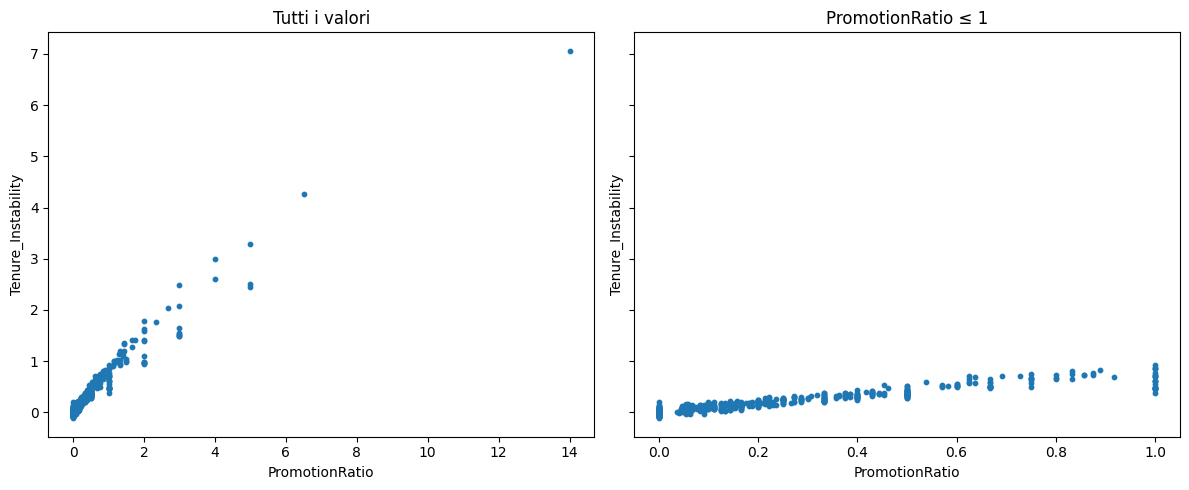

In [ ]:
# Verifichiamo se Tenure_Instability sia ricostruibile come rapporto
# YearsSinceLastPromotion / YearsAtCompany, ovvero se un dipendente
# con poca anzianità e molti anni senza promozione abbia alta instabilità.

corr_yac  = train["YearsAtCompany"].corr(train["Tenure_Instability"])
corr_yslp = train["YearsSinceLastPromotion"].corr(train["Tenure_Instability"])
print(f"Corr YearsAtCompany vs Tenure_Instability:          {corr_yac:.4f}")
print(f"Corr YearsSinceLastPromotion vs Tenure_Instability: {corr_yslp:.4f}")

# PromotionRatio = YearsSinceLastPromotion / YearsAtCompany
# Valori > 1 indicano più anni senza promozione che anni totali in azienda (anomalie logiche)
promotion_ratio = (train["YearsSinceLastPromotion"] / train["YearsAtCompany"]).replace([np.inf, -np.inf], np.nan)

corr_ratio = promotion_ratio.corr(train["Tenure_Instability"])
print(f"Corr PromotionRatio vs Tenure_Instability:          {corr_ratio:.4f}")

# Plot: tutti i valori vs solo PromotionRatio ≤ 1 (escludiamo le anomalie logiche)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(promotion_ratio, train["Tenure_Instability"], s=10)
axes[0].set_title("Tutti i valori")

axes[1].scatter(promotion_ratio[promotion_ratio <= 1], train["Tenure_Instability"][promotion_ratio <= 1], s=10)
axes[1].set_title("PromotionRatio ≤ 1")

for ax in axes:
    ax.set_xlabel("PromotionRatio")
    ax.set_ylabel("Tenure_Instability")

plt.tight_layout()
plt.show()

Si nota dai valori di correlazione e dai plot che valori negativi di Tenure_Instability sono tipicamente associati a pochi anni dall’ultima promozione e/o a un’elevata anzianità aziendale. Questo è coerente con l’idea che una promozione recente indichi crescita e che un’anzianità maggiore riduca l’instabilità (se al denominatore).
Pertanto, i valori negativi non saranno considerati errori, ma situazioni di maggiore stabilità e rientrano nel dominio della variabile.

Si osservano ancora le correlazioni tra gruppi di attributi che per conoscenza di dominio verrebbe da dire possano essere correlati.

In [ ]:
# TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager potrebbero essere correlate positivamente tra loro
group_anzianita = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
# Il livello e lo stipendio potrebbero essere positivamente correlate
group_livello = ['JobLevel', 'MonthlyIncome']
# Età e il numero di anni potrebbero essere positivamente correlate
group_eta = ['Age', 'TotalWorkingYears']

gruppi = {'Anzianità aziendale' : group_anzianita,'JobLevel vs MonthlyIncome': group_livello,'Age vs TotalWorkingYears' : group_eta}

for nome, cols in gruppi.items():
    print("-" * 60)
    print(f"Gruppo: {nome}")
    print("-" * 60)
    print(train[cols].corr().round(2).to_string())
    print()


------------------------------------------------------------
Gruppo: Anzianità aziendale
------------------------------------------------------------
                         TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
TotalWorkingYears                     1.00            0.01               -0.09                     0.11                  0.03
YearsAtCompany                        0.01            1.00                0.06                    -0.05                  0.02
YearsInCurrentRole                   -0.09            0.06                1.00                     0.02                 -0.02
YearsSinceLastPromotion               0.11           -0.05                0.02                     1.00                 -0.05
YearsWithCurrManager                  0.03            0.02               -0.02                    -0.05                  1.00

------------------------------------------------------------
Gruppo: JobLevel vs MonthlyIncom

Tutti i gruppi analizzati risultano sostanzialmente indipendenti. 
Il gruppo delle variabili di anzianità aziendale (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager) mostra valori numerici vicini allo zero.
Analogamente, JobLevel e MonthlyIncome risultano incorrelati (0.0), così come Age e TotalWorkingYears (-0.04), entrambi controintuitivi rispetto alle aspettative di dominio.

#### 5.1.2 Principal Component Analysis

Nessuna colonna con valori NaN.


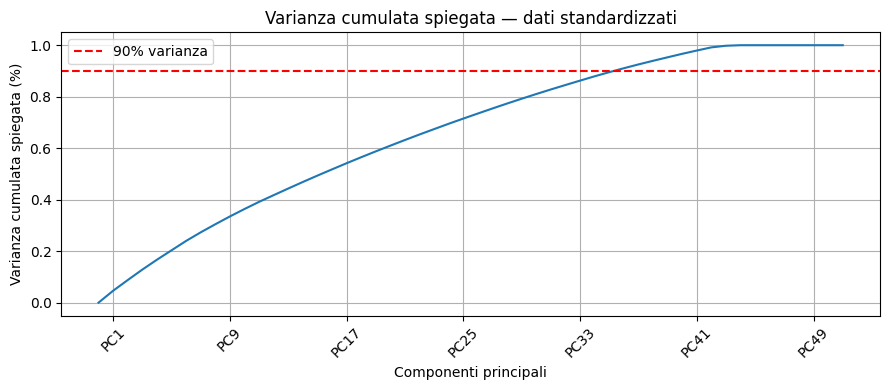

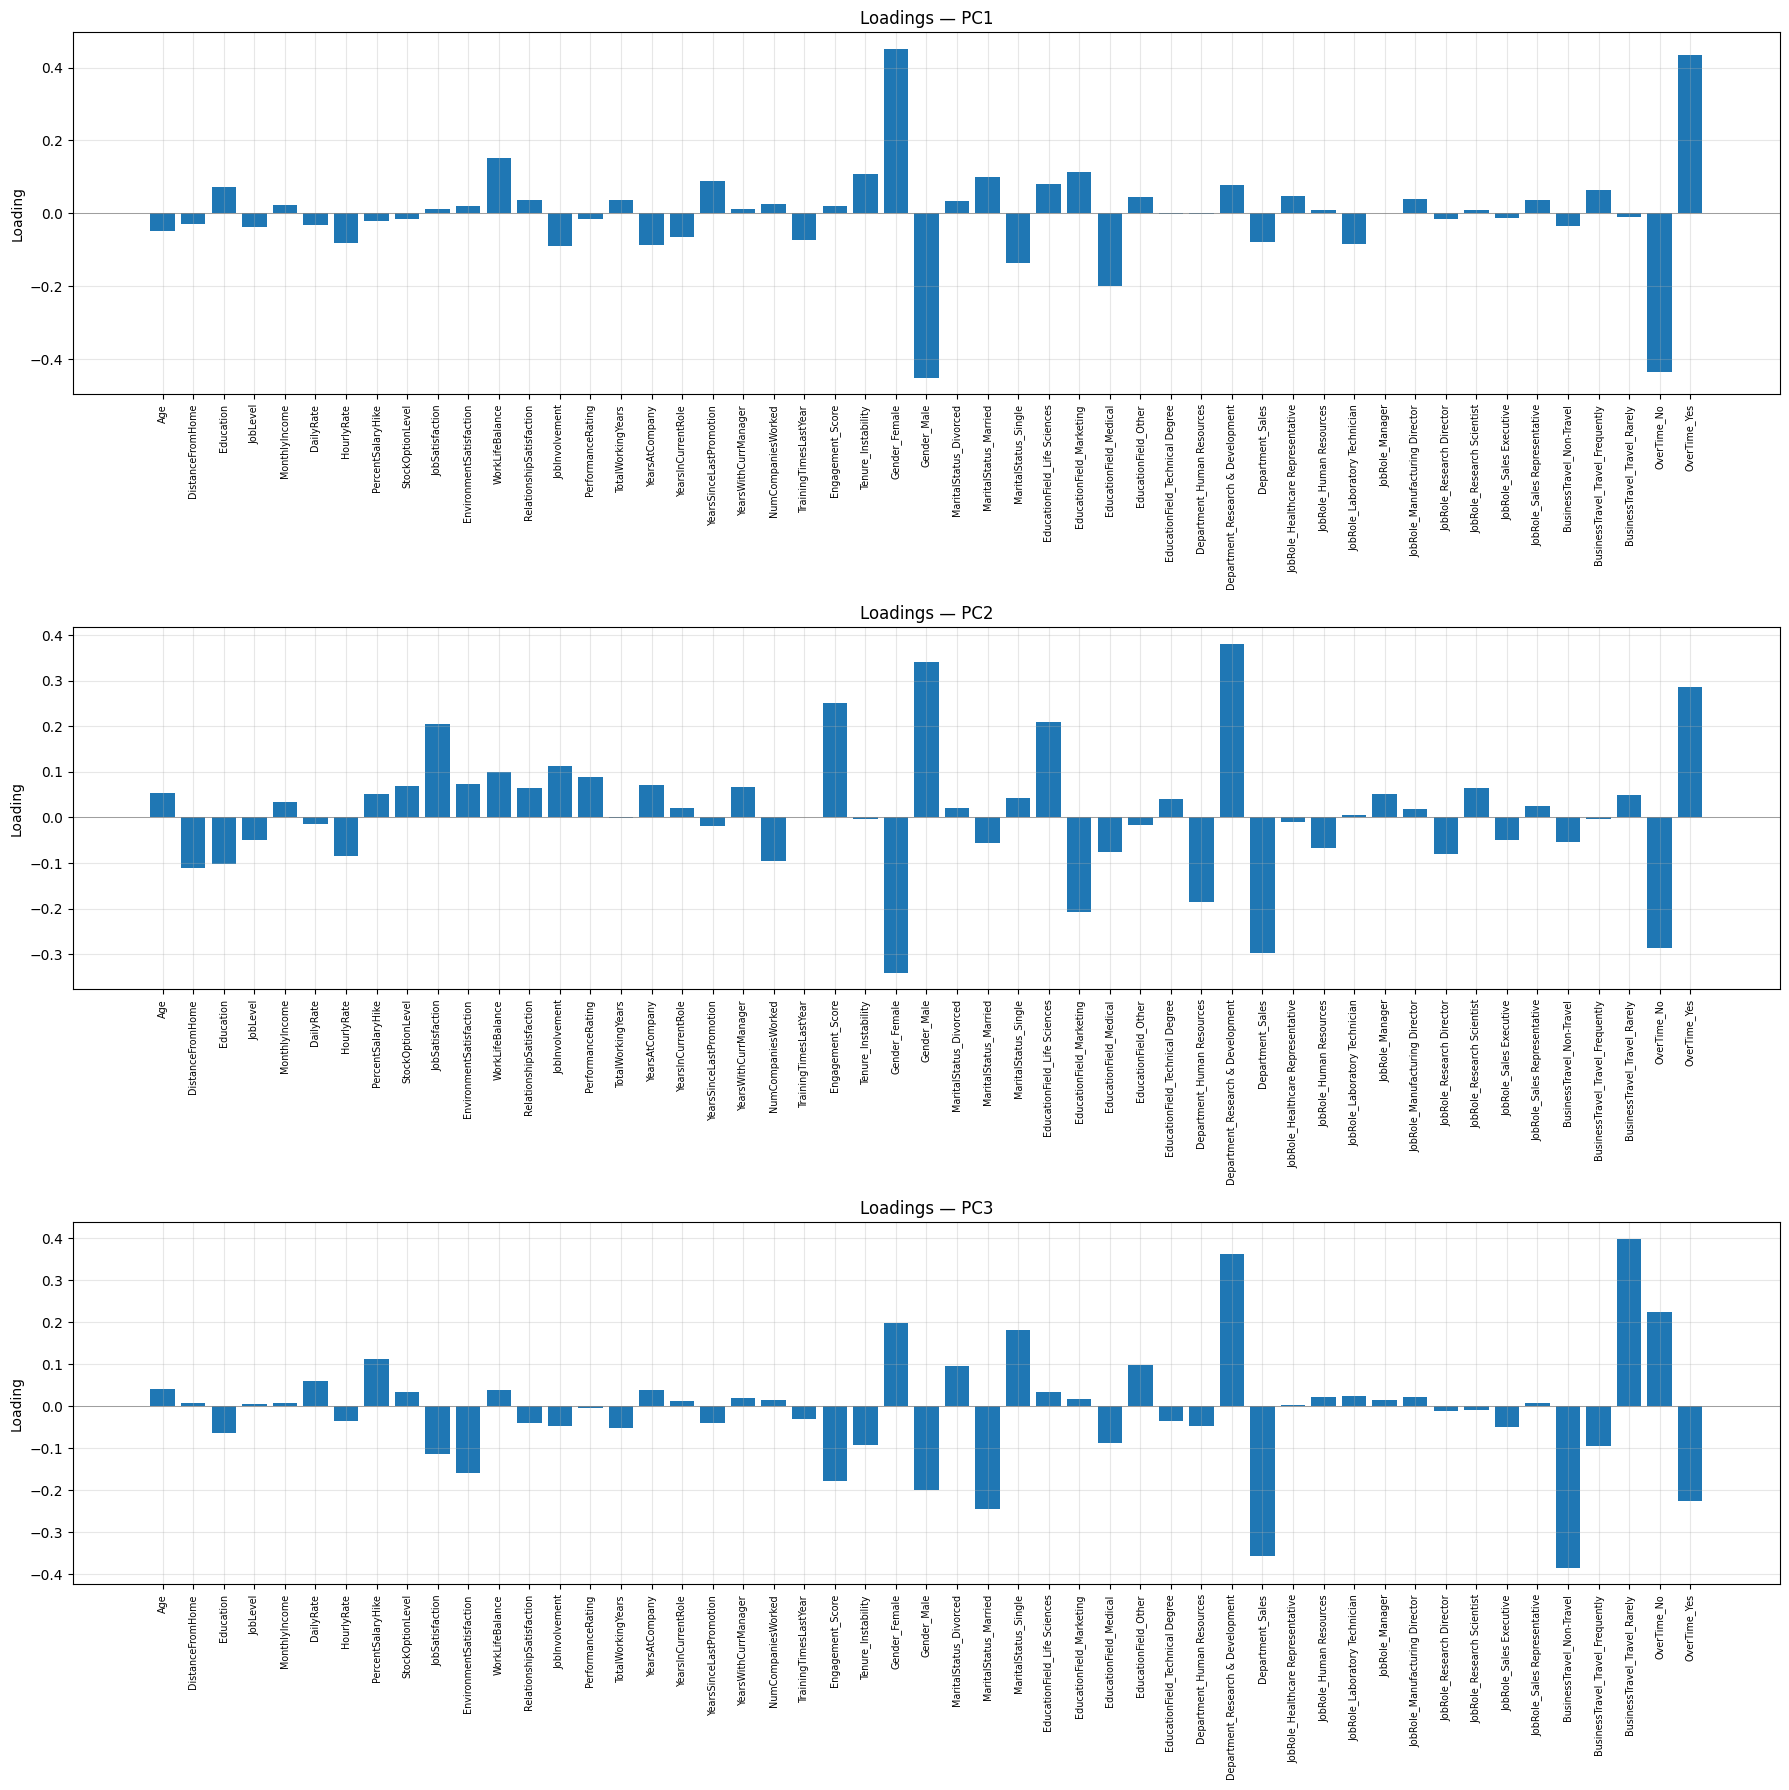

In [ ]:
train_pca = train.copy()
onehot_cols = ['Gender', 'MaritalStatus', 'EducationField','Department', 'JobRole', 'BusinessTravel', 'OverTime']


def print_nan_columns(df):
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]
    if nan_counts.empty:
        print("Nessuna colonna con valori NaN.")
    else:
        print("Colonne con valori NaN:")
        print(nan_counts.sort_values(ascending=False))

print_nan_columns(train)
X_pca = pd.get_dummies(train_pca, columns=onehot_cols, dtype=int)
feature_names = X_pca.columns
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)
plt.figure(figsize=(9, 4))
plt.plot(np.insert(np.cumsum(pca.explained_variance_ratio_), 0, 0))
plt.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
plt.title('Varianza cumulata spiegata — dati standardizzati')
plt.xticks(ticks=np.arange(1, pca.n_components_ + 3, 8),labels=[f'PC{i}' for i in range(1, pca.n_components_ + 3, 8)],rotation=45)
plt.xlabel('Componenti principali')
plt.ylabel('Varianza cumulata spiegata (%)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

n_features = pca.components_.shape[1]

# ── barplot loadings per le prime 3 PC ────────────────────────────────────────
# ogni barra mostra quanto una feature originale contribuisce alla PC
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
for pc_idx, ax in enumerate(axes):
    ax.bar(np.arange(n_features), pca.components_[pc_idx])
    ax.set_xticks(np.arange(n_features))
    ax.set_xticklabels(feature_names, rotation=90, fontsize='x-small')
    ax.set_title(f'Loadings — PC{pc_idx + 1}')
    ax.set_ylabel('Loading')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dalla curva della varianza spiegata, l'informazione è distribuita su molte componenti e nessun piccolo sottoinsieme di feature domina le altre, confermando l'assenza di ridondanza forte nel dataset. I loading elevati di Gender_Male e Gender_Female in PC1 e di OverTime_No e OverTime_yes sono da attribuire principalmente all' one-hot encoding su una variabile binaria, che genera per costruzione due colonne con variabilità massima e correlazione perfetta negativa — non necessariamente un segnale di rilevanza informativa del genere. 
Le componenti PC2 e PC3 mostrano che alcune variabili tendono a variare insieme nello stesso spazio — in PC2 troviamo la conferma di quanto osservato dalla heatmap: JobSatisfaction e EngagementScore mostrano loadings entrambi positivi indicando una correlazione nella seconda direzione principale. Inoltre l'appartenenza al dipartimento R&D (+0.37) o Sales (-0.30) co-varia con JobSatisfaction (+0.20). In PC3 la frequenza di viaggio co-varia con l'appartenenza a Sales: BusinessTravel_Travel_Rarely ha loadings +0.40 e Department_Sales ha loadings -0.37. Tuttavia trattandosi di una combinazione di variabili numeriche e dummy categoriche, non è possibile interpretare questi loading come correlazioni dirette tra le feature originali — rappresentano solo direzioni di variabilità congiunta nello spazio trasformato dalla PCA.
In ogni caso queste analisi descrivono la struttura interna del dataset senza considerare la label: servono a intuire quali attributi portano informazione indipendente e quali sono ridondanti. La relazione con Attrition richiede un'analisi separata svolta di seguito. 

### Conclusioni — Feature Redundancy
Dalle analisi di correlazione e PCA emergono due gruppi di ridondanza:

1. `Engagement_Score` è ricostruibile approssimativamente come combinazione lineare di
   `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance` e `JobInvolvement`.
2. `Tenure_Instability` è ricostruibile con correlazione r = 0.97 dal rapporto
   `YearsSinceLastPromotion / YearsAtCompany`.

In entrambi i casi si sceglie di rimuovere la feature derivata (`Engagement_Score` e `Tenure_Instability`)
e mantenere le componenti originali. La motivazione è che le componenti potrebbero avere effetti
distinti e separabili sull'attrition: per esempio, un modello potrebbe rilevare che `WorkLifeBalance`
impatta l'attrition in modo diverso da `JobInvolvement`, informazione che andrebbe persa collassando
tutto in un unico score. Mantenere le componenti preserva questa granularità interpretativa,
che è rilevante in un contesto HR dove l'obiettivo non è solo predire ma anche capire su quali fattori agire.

In [ ]:
# modificare train e train_with_label

#### 5.1.3 Features vs label
Si osservano le distribuzione delle variabili numeriche, separate per classe di Attrition per intuire visivamente se ci possono essere attributi che discriminano maggiormente di altri

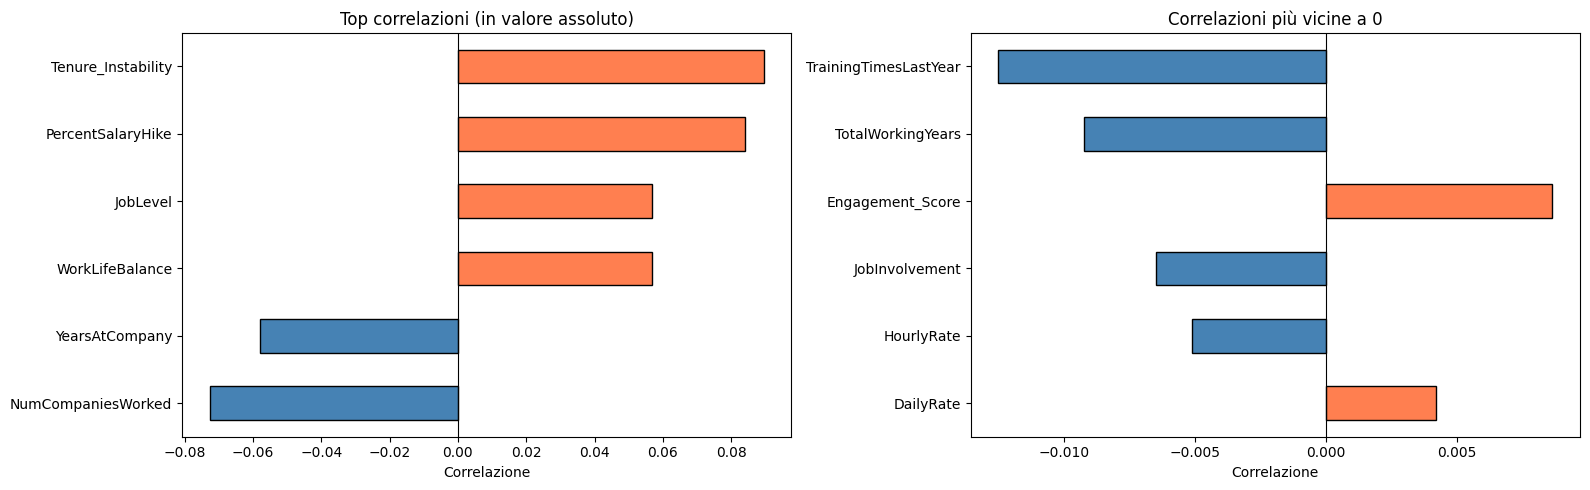

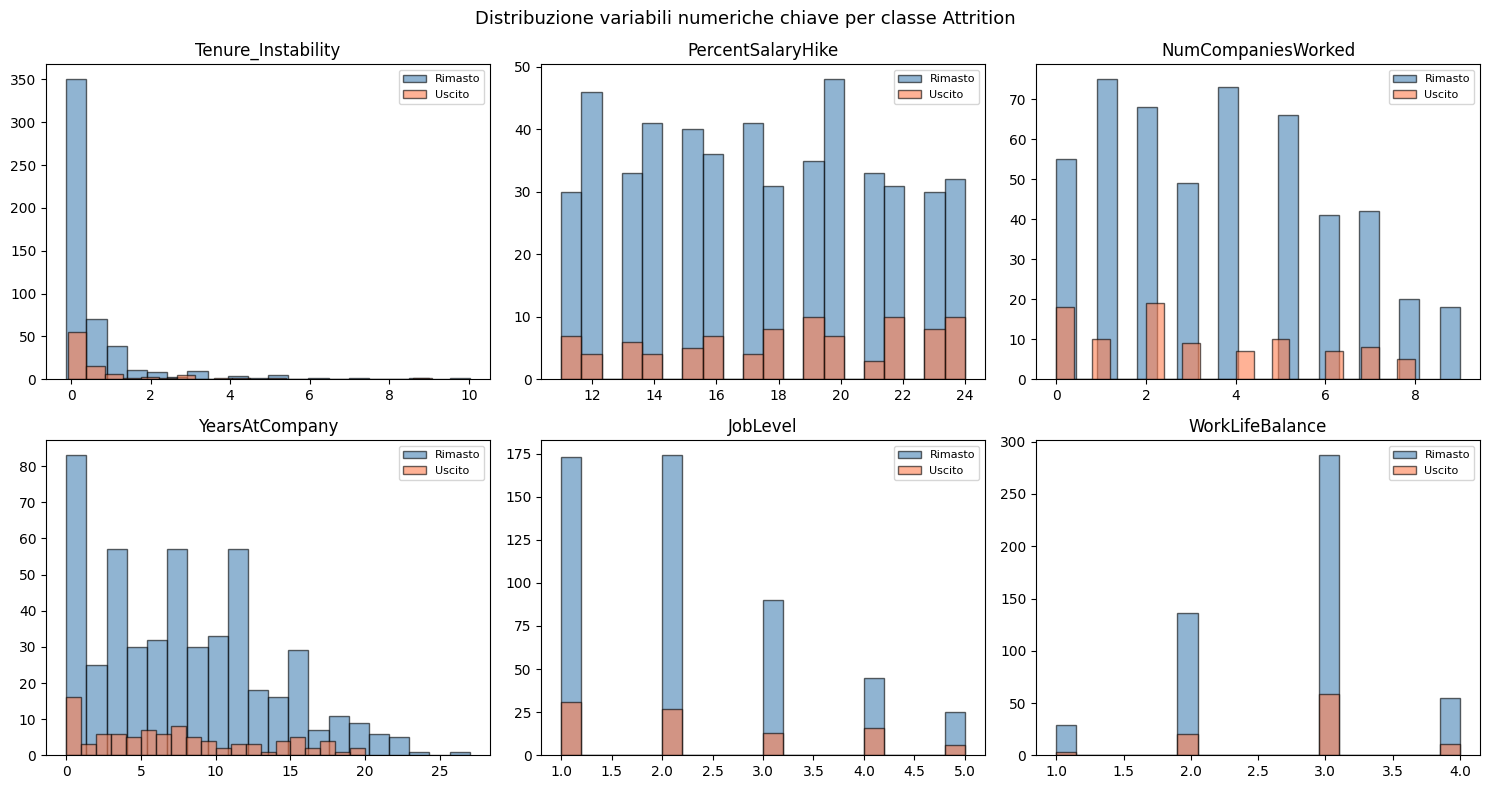

In [ ]:
## ATTRIBUTI NUMERICI

corr_target = train_with_label.select_dtypes(include=['int64', 'float64']).corr()['Attrition']
corr_target = corr_target.drop('Attrition')
corr_sorted = corr_target.reindex( corr_target.abs().sort_values(ascending=False).index)
corr_sorted_low = corr_target.reindex(corr_target.abs().sort_values(ascending=True).index)
top_high = corr_sorted.head(6).sort_values()
top_low = corr_sorted_low.head(6)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_high.plot( kind='barh', ax=axes[0], color=top_high.map(lambda x: 'coral' if x > 0 else 'steelblue'), edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top correlazioni (in valore assoluto)')
axes[0].set_xlabel('Correlazione')
top_low.plot(kind='barh',ax=axes[1],color=top_low.map(lambda x: 'coral' if x > 0 else 'steelblue'),   edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlazioni più vicine a 0')
axes[1].set_xlabel('Correlazione')
plt.tight_layout()
plt.show()

key_num = corr_sorted.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_num):
    for val, label, color in [(0, 'Rimasto', 'steelblue'), (1, 'Uscito', 'coral')]:
        subset = train[train_with_label['Attrition'] == val][feat].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuzione variabili numeriche chiave per classe Attrition', fontsize=13)
plt.tight_layout()
plt.show()



Tra le variabili numeriche i coefficienti di correlazione con attrition sono tutti compresi tra -0.08 e +0.09. Sono correlazioni lineari deboli. Con correlazioni più forti date da NumCompaniesWorked. 
Quindi non ci sono variabili numeriche significamente predittive secondo la metrica della correlazione lineare. Ciò può essere osservato anche dalle distribuzioni (istogrammi) di attrition che non sembrano essere tanto differenti.
Invece tra le variabili meno correlate ci sono "HourlyRate" e "MonthlyRate". Quindi si può considerare successivamente se rimuoverli.

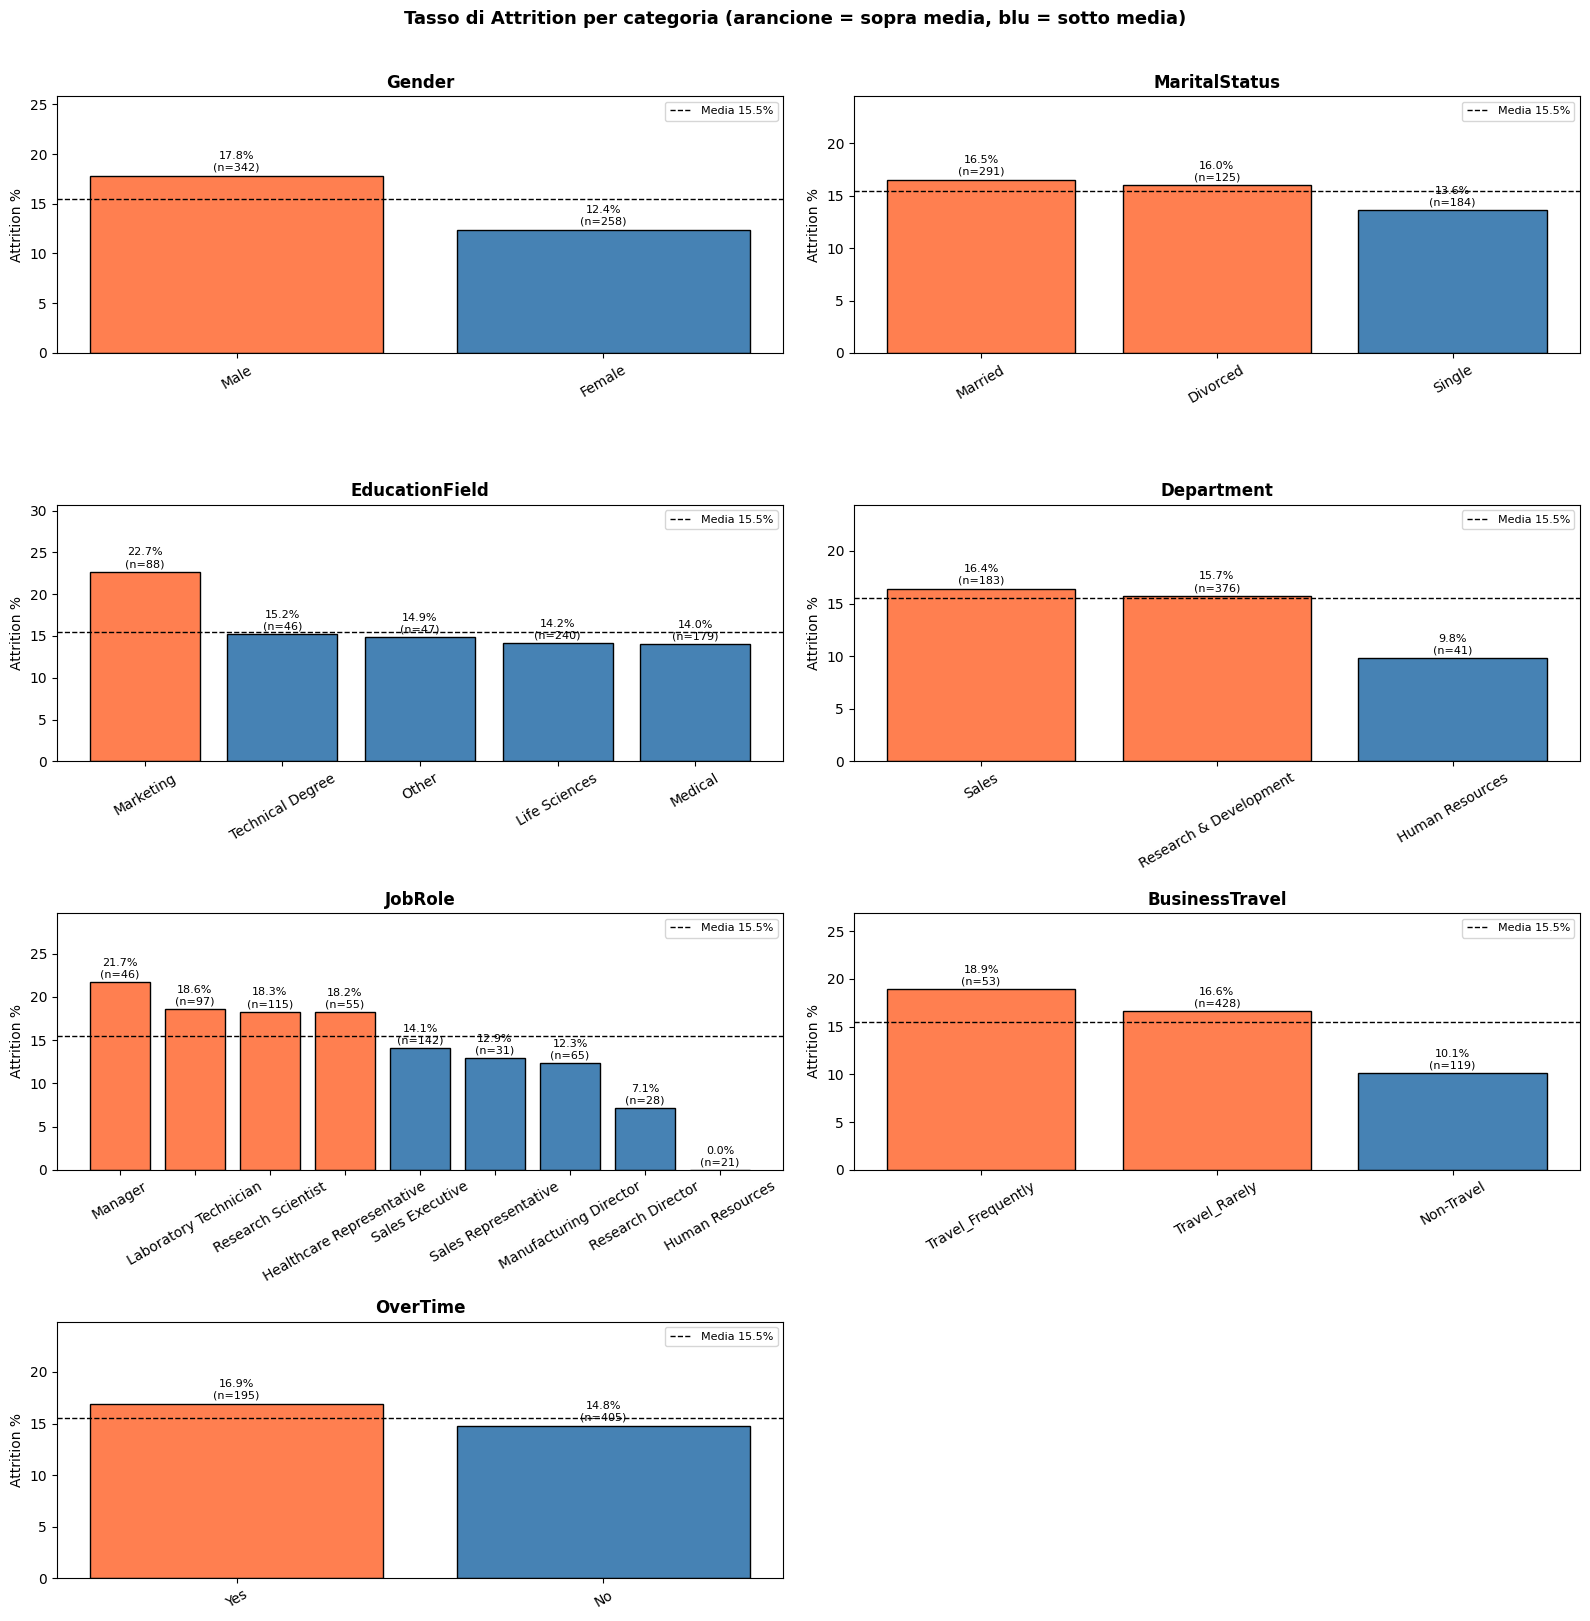

In [ ]:
## ATTRIBUTI CATEGORICI
obj_cols = train_with_label.select_dtypes(include='object').columns.tolist()
n_cols = 2
n_rows = math.ceil(len(obj_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
mean_attrition = train_with_label['Attrition'].mean() * 100
for i, col in enumerate(obj_cols):
    rates = (train_with_label.groupby(col)['Attrition'].agg(['sum', 'count']).rename(columns={'sum': 'Usciti', 'count': 'Totale'}))
    rates['Attrition%'] = (rates['Usciti'] / rates['Totale'] * 100).round(1)
    rates = rates.sort_values('Attrition%', ascending=False)
    colors = ['coral' if v > mean_attrition else 'steelblue' for v in rates['Attrition%']]
    bars = axes[i].bar(rates.index, rates['Attrition%'], color=colors, edgecolor='black')
    # linea media dataset
    axes[i].axhline(mean_attrition, color='black', linestyle='--', linewidth=1, label=f'Media {mean_attrition:.1f}%')
    # etichette sulle barre
    for bar, (_, row) in zip(bars, rates.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.3,f"{row['Attrition%']}%\n(n={int(row['Totale'])})",ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Attrition %')
    axes[i].set_ylim(0, rates['Attrition%'].max() + 8)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Tasso di Attrition per categoria (arancione = sopra media, blu = sotto media)',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Anche tra le categoriche non si notano variabili altamente discriminanti. Notiamo leggere indicazioni:
- Chi viaggia di più lascia di più (vedi BusinessTravel)
- Chi lavora nel Marketing tenderà a lasciare maggiormente rispetto agli altri campi
- Tendenzialmente l'attrition dipende dal ruolo: manager ha mediamente alta attrition.
Notiamo che attributi come OverTime non contribuirebbero significativamente all'attrition.

### Conclusioni — Feature non informative
Dalle analisi si evidenziano

**Variabili numeriche**: tutte le correlazioni lineari con Attrition sono comprese tra -0.08 e +0.09,
indicando assenza di predittori numerici forti. Le distribuzioni per classe (rimasto vs uscito)
risultano visivamente simili per la maggior parte delle variabili. Le variabili `HourlyRate`
e `DailyRate` risultano invece le meno informative e sono candidate alla rimozione.

**Variabili categoriche**: nessuna variabile mostra un tasso di attrition nettamente discriminante.
Si osservano segnali deboli su `BusinessTravel` e `JobRole`.
`OverTime` non sembra discriminare significativamente l'attrition in questo dataset.

Si decide quindi di non considerare attributi quali `HourlyRate`, `DailyRate` e `OverTime`.

In [ ]:
'''
cols_to_drop = ['Engagement_Score', 'Tenure_Instability', 'HourlyRate', 'DailyRate']
train = train.drop(columns=cols_to_drop)
train_with_label = train_with_label.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)
'''




"\ncols_to_drop = ['Engagement_Score', 'Tenure_Instability', 'HourlyRate', 'DailyRate']\ntrain = train.drop(columns=cols_to_drop)\ntrain_with_label = train_with_label.drop(columns=cols_to_drop)\ntest = test.drop(columns=cols_to_drop)\n"

### 5.2 Discretization

La discretizzazione è un processo di data reduction che riduce la cardinalità del dominio di un attributo . Si applica in modo non supervisionato tramite equal-width o equal-frequency binning.
Le feature discretizzate vengono preservate nel dataset parallelamente alle versioni continue originali. Le versioni continue saranno preferite per Decision Tree e Random Forest, che applicano internamente una discretizzazione supervisionata ottimale rispetto al target. Le versioni discretizzate potranno risultare più adatte in presenza di relazioni non lineari tra feature e Attrition e sono comunque utili per l'analisi esplorativa e la comprensione del dataset.
Operativamente, prima visualizziamo gli attributi potenzialmente discretizzabili, come si distribuiscono (ignoro i vari years... aspettando risposta da prof).
Ignoriamo tutti gli attributi che hanno dominio discreto in [1,4] o [1,5] e i categorici, ci soffermiamo quindi su: 
* Age;
* DistanceFromHome;
* MonthlyIncome;
* DailyRate (Rischio overfitting --> ignoro questo attributo in quanto l'informazione rilevante proviene da MonthlyIncome);
* HourlyRate (Rischio overfitting --> ignoro questo attributo in quanto l'informazione rilevante proviene da MonthlyIncome);
* PercentSalaryHike;
* TotalWorkingYears;
* YearsAtCompany;
* YearsInCurrentRole;
* YearsSinceLastPromotion;
* YearsWithCurrManager;
* Engagement_Score (--> sarà eliminato --> ignoro);
* Tenure_Instability (da valutare se eliminare o meno l'attributo --> lo considero).

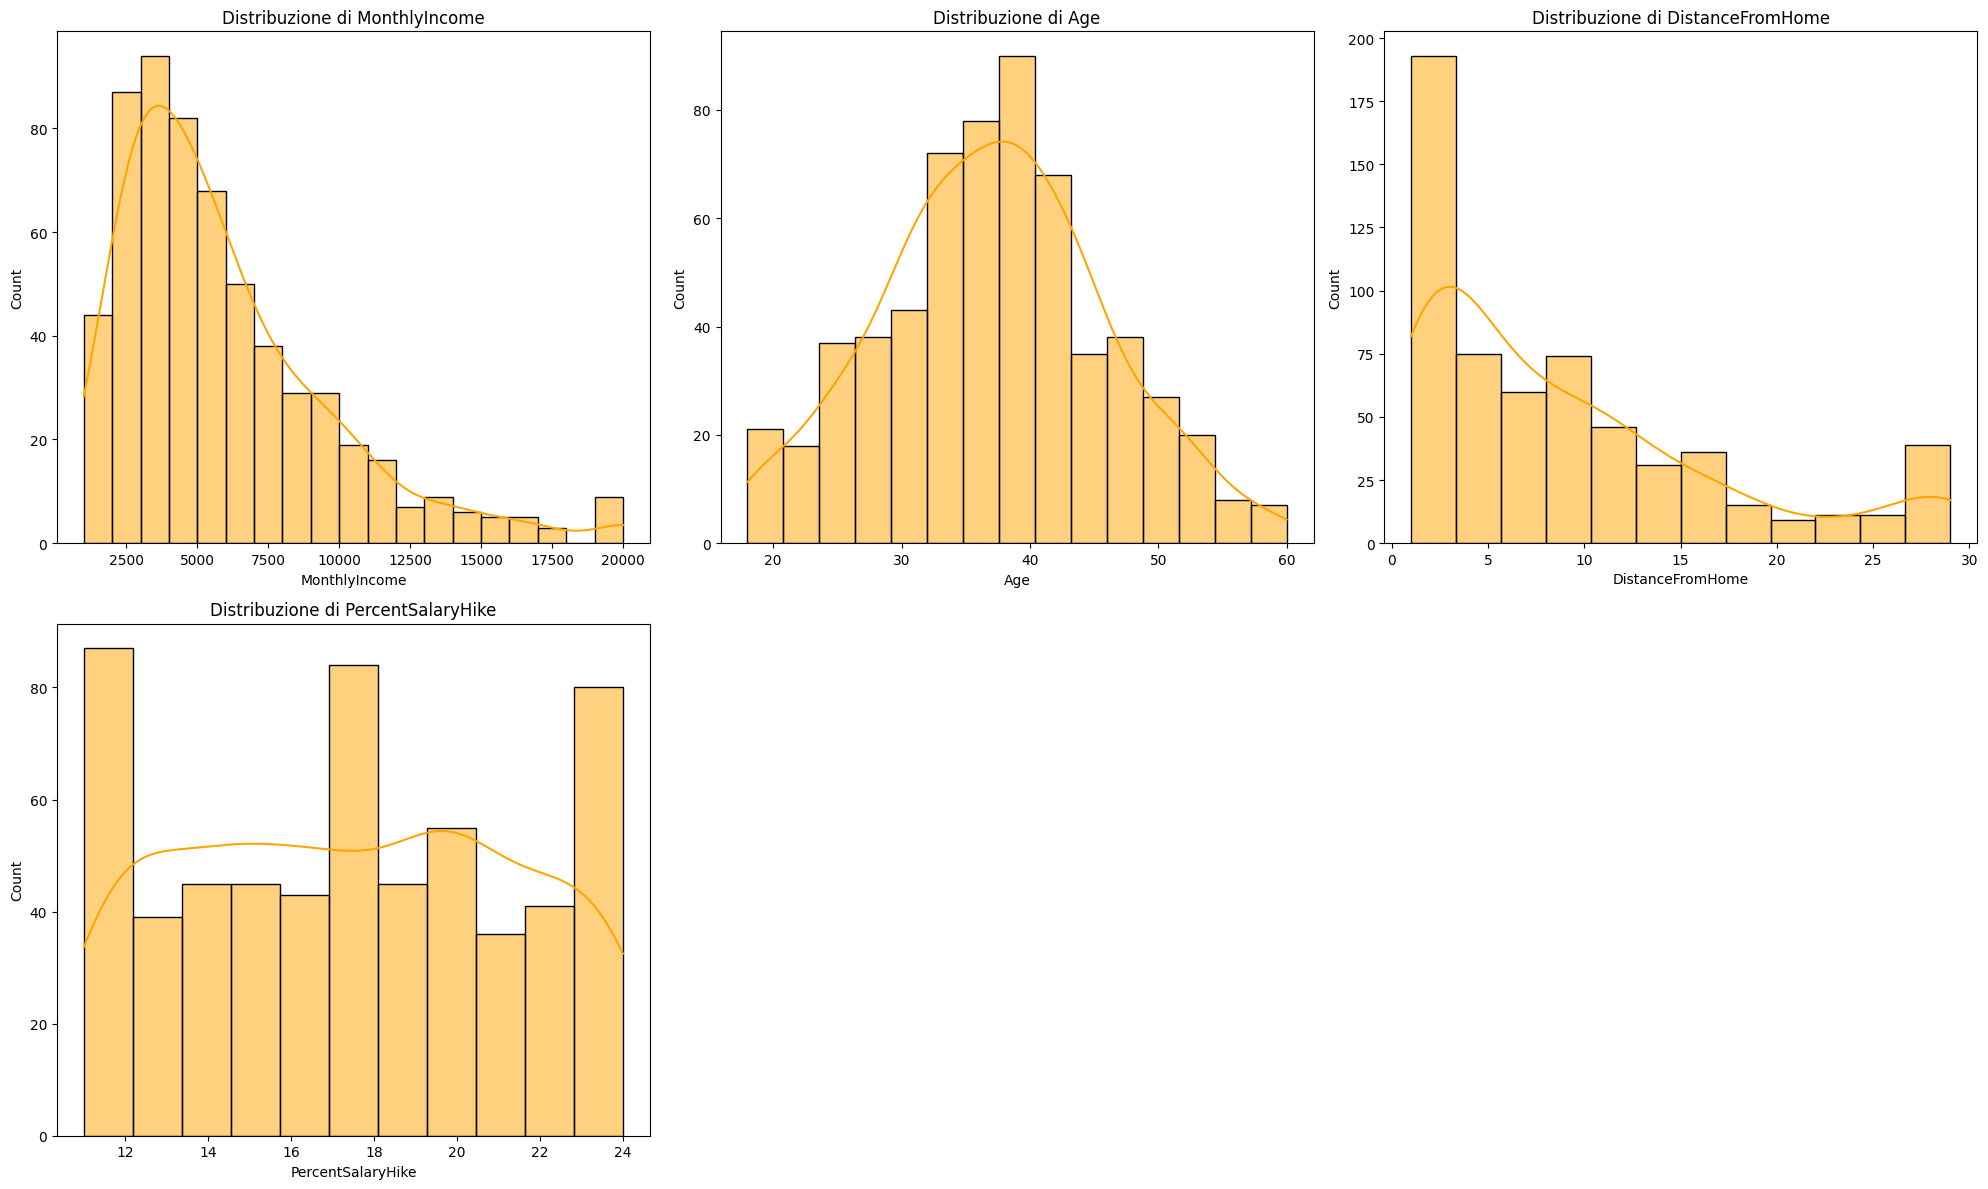

MonthlyIncome: 570 valori unici
Age: 42 valori unici
DistanceFromHome: 29 valori unici
PercentSalaryHike: 14 valori unici


In [ ]:
# Lista dei candidati su cui riflettere (esclusi gli "Years" per ora)
candidati_riflessione = ['MonthlyIncome', 'Age', 'DistanceFromHome', 'PercentSalaryHike']
plt.figure(figsize=(20, 12))
for i, col in enumerate(candidati_riflessione, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_with_label[col], kde=True, color='orange')
    plt.title(f'Distribuzione di {col}')
plt.tight_layout()
plt.show()
for col in candidati_riflessione:
    print(f"{col}: {train_with_label[col].nunique()} valori unici")

In [ ]:
# Creiamo due versioni parallele del dataset:
# - train / train_with_label: versione continua originale, usata per Decision Tree, Random Forest e Logistic Regression
# - train_discr / train_with_label_discr: versione con le feature discretizzate, da esplorare in fase di modellazione
train_discr = train.copy()
train_with_label_discr = train_with_label.copy()

Da questa visualizzazione risulta:

1. MonthlyIncome - Si discretizza per frequenza (Equal Frequency con 5 bin) per far sì che ogni fascia abbia lo stesso numero di oggetti. Infatti la sua distribuzione presenta una distribuzione fortemente asimmetrica a destra. Le etichette seguiranno una logica simmetrica e intuitiva dal punto di vista HR: Molto Basso, Basso, Medio, Alto, Molto Alto.
2. Age - Presenta una distribuzione a campana (pseudonormale). Si sceglie una discretizzazione per frequenza (Equal Frequency con 5 bin) tramite quantili. Questa soluzione evita di svuotare le code della distribuzione (i giovanissimi e i dipendenti più anziani), garantendo che tutti i gruppi abbiano abbastanza dati. Mappa 5 fasce generazionali e di carriera bilanciate: Giovani, Giovani Adulti, Adulti, Senior, Pre-Pensionamento, utile per analizzare se le fasce più giovani tendono maggiormente all'abbandono.
3. DistanceFromHome - Qui l'approccio automatico a frequenza creerebbe micro-intervalli artificiali e poco significativi (es. dividendo chi fa 2 km da chi ne fa 4). A rigor di logica, si preferisce optare per 3 bin personalizzati custom Cut con tagli scelti opportunamente sulla base dei diversi atteggiamenti logistici: In_Zona (0-3 km, mobilità dolce a piedi/bici), Urbano_Breve (3-10 km, spostamento cittadino locale veloce) e Pendolari (oltre i 10 km, tratta extraurbana pesante). Ciò sempre in vista dell'obiettivo dell'analisi: per esempio essere tra i pendolari potrebbe portare un rischio maggiore di abbandono.
5. PercentSalaryHike - Presenta una granularità molto ridotta e pochissimi valori unici nel dataset -> NO DISCRETIZZAZIONE.




QUESTI DOVREBBERO ESSERE GIA' RIMOSSI:
4. Tenure_Instability - Presenta una distribuzione fortemente asimmetrica. Di conseguenza, diventa ottimale applicare una discretizzazione Equal Frequency a 4 bin (quartili). Questo permette di dividere la forza lavoro in quattro segmenti numericamente speculari e stabili (Stabile, Quasi Stabile, Instabilità Media, Alta Instabilità), isolando con precisione la fascia critica di chi ha carriere storicamente frammentate senza subire il disturbo degli outlier, che sono stati rimossi.
6. Engagement_Score - Essendo un attributo destinato all'eliminazione definitiva dal dataset a causa dell'altissimo numero di valori mancanti e delle ridondanze informative -> IGNORO / NO DISCRETIZZAZIONE.

In [ ]:
## UTILS
def plot_discretization(df, bin_col, bin_edges, labels, title, xlabel, unit='', palette='viridis', figsize=(8, 4)):
    counts = df[bin_col].value_counts()
    print(f"{'Fascia':<20} | {'Intervallo':<25} | {'Conteggio'}")
    print("-" * 58)
    for i, label in enumerate(labels):
        intervallo = f"[{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}] {unit}"
        print(f"{label:<20} | {intervallo:<25} | {counts.get(label, 0)}")
    print("\n" + "=" * 58 + "\n")
    tick_labels = [f"{labels[i]}\n{bin_edges[i]:.0f}-{bin_edges[i+1]:.0f} {unit}" for i in range(len(labels))]
    plt.figure(figsize=figsize)  # ← usa il parametro
    sns.countplot(x=bin_col, data=df, palette=palette, hue=bin_col, legend=False)
    plt.gca().set_xticks(range(len(labels)))
    plt.gca().set_xticklabels(tick_labels)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel("Numero di Dipendenti")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',(p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='center', xytext=(0, 5),
                    textcoords='offset points', fontsize=10)
    plt.tight_layout()
    plt.show()

#### 5.2.1 Discretizzazione MonthlyIncome
La scelta di discretizzare l'attributo MonthlyIncome in 5 bin risponde a una precisa logica di dominio e di business transazionale. Dal punto di vista delle Risorse Umane, una suddivisione a 5 intervalli mappa perfettamente i cinque macro-livelli retribuitivi e gerarchici standard di un'organizzazione (Junior, Professional, Senior, Middle Management, Executive), garantendo una categorizzazione simmetrica (Molto Basso, Basso, Medio, Alto, Molto Alto). Questo livello di granularità evita la frammentazione artificiale del dato, preservando il significato semantico delle fasce salariali e garantendo la massima interpretabilità delle regole decisionali estratte dai modelli per lo sviluppo di strategie di retention.
Si preservano entrambe le versioni dell'attributo nel dataset: valore continuo e valore discretizzato
La scelta definitiva di quale versione includere nei modelli verrà effettuata in fase di 
sperimentazione, valutando l'impatto sulle metriche di classificazione.

Fascia               | Intervallo                | Conteggio
----------------------------------------------------------
Molto_Basso          | [1009.0 - 2941.2] €       | 120
Basso                | [2941.2 - 4203.2] €       | 120
Medio                | [4203.2 - 5824.6] €       | 120
Alto                 | [5824.6 - 8482.6] €       | 120
Molto_Alto           | [8482.6 - 19999.0] €      | 120




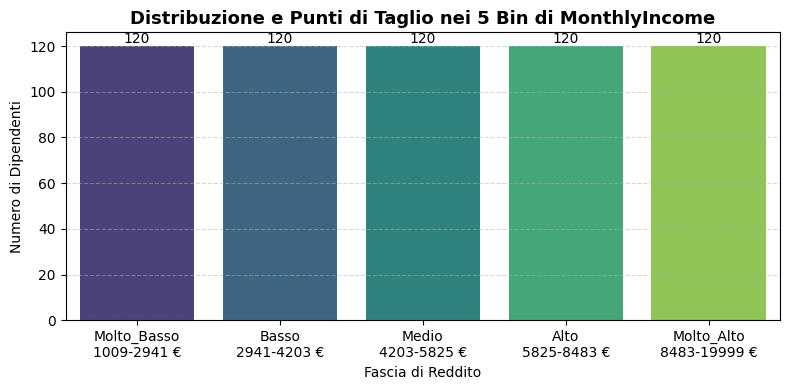

In [ ]:
# MonthlyIncome
train_with_label_discr['MonthlyIncome'], income_edges = pd.qcut(
    train_with_label_discr['MonthlyIncome'], q=5,
    labels=['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto'], retbins=True)
train_discr['MonthlyIncome'] = train_with_label_discr['MonthlyIncome']

plot_discretization(train_discr, 'MonthlyIncome', income_edges,
    labels=['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto'],
    title='Distribuzione e Punti di Taglio nei 5 Bin di MonthlyIncome',
    xlabel='Fascia di Reddito', unit='€', palette='viridis')



#### 5.2.2 Discretizzazione Age
Prima di discretizzare l'età, abbiamo guardato come si distribuiva nel dataset. I dati non sono uniformi: si concentrano quasi tutti nella fascia centrale (tra i 30 e i 45 anni), mentre ci sono pochissimi dipendenti giovanissimi o vicini alla pensione.
Se avessimo usato una discretizzazione ad ampiezza costante (Equal Width), dividendo ad esempio l'età in blocchi fissi di 8 o 10 anni, avremmo ottenuto un bin centrale stracolmo di record e le code quasi vuote.
Scegliendo invece i quantili (Equal Frequency a 5 bin), abbiamo forzato ogni gruppo a contenere esattamente lo stesso numero di dipendenti (circa il 20% del totale ciascuno). Dal punto di vista dei dati, gli intervalli si adattano da soli. 
In più, dividere l'organico in queste 5 fasce (Giovani, Giovani Adulti, Adulti, Senior, Pre-Pensionamento) rispecchia le reali tappe di carriera in azienda. 

Fascia               | Intervallo                | Conteggio
----------------------------------------------------------
Giovani              | [18.0 - 30.0] anni        | 137
Giovani_Adulti       | [30.0 - 35.0] anni        | 122
Adulti               | [35.0 - 39.0] anni        | 109
Senior               | [39.0 - 44.0] anni        | 121
Pre_Pensionamento    | [44.0 - 60.0] anni        | 111




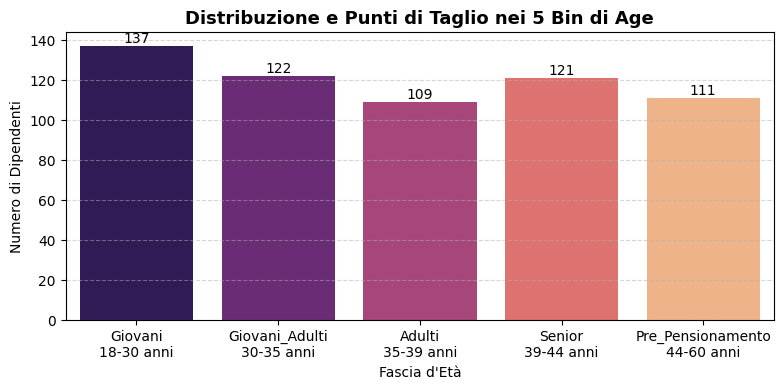

In [ ]:
# Age
train_with_label_discr['Age'], age_edges = pd.qcut(
    train_with_label_discr['Age'], q=5,
    labels=['Giovani', 'Giovani_Adulti', 'Adulti', 'Senior', 'Pre_Pensionamento'], retbins=True)
train_discr['Age'] = train_with_label_discr['Age']

plot_discretization(train_with_label_discr, 'Age', age_edges,
    labels=['Giovani', 'Giovani_Adulti', 'Adulti', 'Senior', 'Pre_Pensionamento'],
    title='Distribuzione e Punti di Taglio nei 5 Bin di Age',
    xlabel="Fascia d'Età", unit='anni', palette='magma')


#### 5.2.2 Discretizzazione DistanceFromHome

Si è preferito optare per una discretizzazione Custom a 3 soli bin, applicando dei punti di taglio selezionati appositamente sulla base delle distanze. L'idea guida è che i dipendenti modificano il proprio atteggiamento verso l'azienda e verso il proprio lavoro a seconda dello stress e delle modalità del viaggio giornaliero.
Gli intervalli sono stati scelti per isolare comportamenti radicalmente diversi:
In Zona (0 - 3 km): Rappresenta la fascia della "mobilità dolce". Chi abita così vicino può raggiungere l'ufficio a piedi o in bicicletta in pochi minuti. Ha zero stress legato al traffico o ai trasporti e gode del massimo comfort logistico.
Urbano Breve (3 - 10 km): È la fascia degli spostamenti cittadini a breve raggio. Il dipendente si muove tipicamente in auto o con i mezzi pubblici locali. Il tragitto richiede comunque un impegno di tempo ridotto (di solito sotto i 15-20 minuti) e non impatta pesantemente sulla routine quotidiana.
Pendolari (oltre i 10 km): Rappresenta la condizione del vero e proprio pendolarismo extraurbano. Chi rientra in questo gruppo deve affrontare tratte più lunghe o combinazioni di mezzi, comportando anche costi economici evidenti (carburante o abbonamenti). 

Fascia               | Intervallo                | Conteggio
----------------------------------------------------------
In_Zona              | [0.0 - 3.0] km            | 193
Urbano_Breve         | [3.0 - 10.0] km           | 209
Pendolari            | [10.0 - 29.0] km          | 198




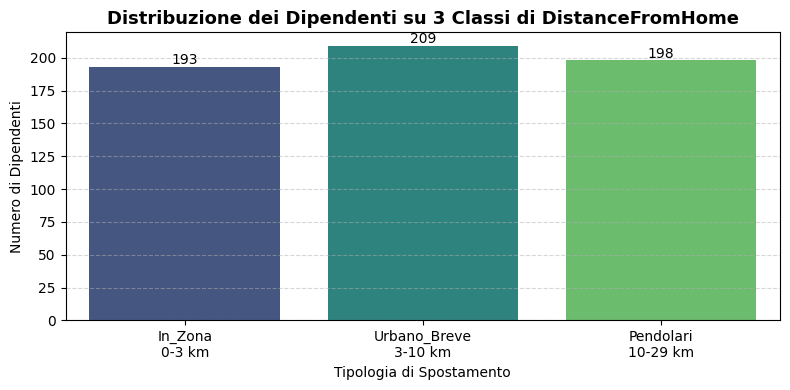

In [ ]:
# DistanceFromHome
max_dist      = train_with_label_discr['DistanceFromHome'].max()
custom_bins   = [0, 3, 10, max_dist]
custom_labels = ['In_Zona', 'Urbano_Breve', 'Pendolari']

train_with_label_discr['DistanceFromHome'] = pd.cut(
    train_with_label_discr['DistanceFromHome'], bins=custom_bins,
    labels=custom_labels, include_lowest=True)
train_discr['DistanceFromHome'] = train_with_label_discr['DistanceFromHome']


plot_discretization(train_with_label_discr, 'DistanceFromHome', custom_bins,
    labels=custom_labels,
    title='Distribuzione dei Dipendenti su 3 Classi di DistanceFromHome',
    xlabel='Tipologia di Spostamento', unit='km', palette='viridis')



In [ ]:
# Test (stessi bin dal train dataset)
test_discr = test.copy()
test_discr['MonthlyIncome'] = pd.cut(test_discr['MonthlyIncome'], bins=income_edges,
    labels=['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto'], include_lowest=True)
test_discr['Age'] = pd.cut(test_discr['Age'], bins=age_edges,
    labels=['Giovani', 'Giovani_Adulti', 'Adulti', 'Senior', 'Pre_Pensionamento'], include_lowest=True)
test_discr['DistanceFromHome'] = pd.cut(test_discr['DistanceFromHome'], bins=custom_bins,
    labels=custom_labels, include_lowest=True)

### 5.3 Encoding

#### 5.3.1 Encoding variabili categoriche
Si mappano attributi categoriali in un dominio numerico. Le principali tecniche sono label encoding - maggiormente adatto nel caso di variabili ordinali - e one hot encoding - preferibile nel caso di variabili non ordinali. Nel nostro caso le variabili 'Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel' e 'OverTime' non possiedono nozione di ordine quindi si esegue una codifica one-hot.

In [ ]:
# One-hot encoding variabili nominali su tutti i dataset
onehot_cols = ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']

train                  = pd.get_dummies(train,                  columns=onehot_cols)
train_discr            = pd.get_dummies(train_discr,            columns=onehot_cols)
train_with_label       = pd.get_dummies(train_with_label,       columns=onehot_cols)
train_with_label_discr = pd.get_dummies(train_with_label_discr, columns=onehot_cols)
test                   = pd.get_dummies(test,                   columns=onehot_cols)
test_discr             = pd.get_dummies(test_discr,             columns=onehot_cols)

# Allineamento colonne test → train (fill_value=0 per categorie mancanti)
test_attrition       = test['Attrition'].values       if 'Attrition' in test.columns       else None
test_discr_attrition = test_discr['Attrition'].values if 'Attrition' in test_discr.columns else None

test       = test.reindex(columns=train.columns,              fill_value=0)
test_discr = test_discr.reindex(columns=train_discr.columns,  fill_value=0)

if test_attrition       is not None: test['Attrition']       = test_attrition
if test_discr_attrition is not None: test_discr['Attrition'] = test_discr_attrition

# bool → int su tutti i dataset
for df in [train, train_discr, train_with_label, train_with_label_discr, test, test_discr]:
    bool_cols = [c for c in df.columns if df[c].dtype == bool]
    df[bool_cols] = df[bool_cols].astype(int)

#### 5.3.2 Encoding variabili ordinali (date dalla discretization)
Essendo variabili ordinali (derivano infatti dalla discretizzazione di variabili continue) preserviamo l'informazione sull'ordine usando il label encoding

In [ ]:
income_order   = {'Molto_Basso': 0, 'Basso': 1, 'Medio': 2, 'Alto': 3, 'Molto_Alto': 4}
age_order      = {'Giovani': 0, 'Giovani_Adulti': 1, 'Adulti': 2, 'Senior': 3, 'Pre_Pensionamento': 4}
distance_order = {'In_Zona': 0, 'Urbano_Breve': 1, 'Pendolari': 2}

for df in [train_discr, train_with_label_discr, test_discr]:
    df['MonthlyIncome']    = df['MonthlyIncome'].map(income_order)
    df['Age']              = df['Age'].map(age_order)
    df['DistanceFromHome'] = df['DistanceFromHome'].map(distance_order)

### 5.4 Normalization
Si utilizza come metodo di normalizzazione il min max scaler, questo perchè esso rimane un metodo robusto in assenza di outliers (rimossi durante il preprocessing) ed è preferibile nel caso ci siano molteplici variabili ordinali che quindi difficilmente possiedono distribuzione simil gaussiana.

In [ ]:
# Normalizzazione MinMax — solo colonne non binarie (esclude le dummy 0/1)
def get_num_cols(df):
    skip = {'Attrition'}
    return [c for c in df.columns if df[c].nunique() > 2 and c not in skip]

# Continuo
num_cols = get_num_cols(train)
scaler = MinMaxScaler()
train[num_cols]            = scaler.fit_transform(train[num_cols])
train_with_label[num_cols] = scaler.transform(train_with_label[num_cols])
test[num_cols]             = scaler.transform(test[num_cols])

# Discretizzato
num_cols_discr = get_num_cols(train_discr)
scaler_discr = MinMaxScaler()
train_discr[num_cols_discr]            = scaler_discr.fit_transform(train_discr[num_cols_discr])
train_with_label_discr[num_cols_discr] = scaler_discr.transform(train_with_label_discr[num_cols_discr])
test_discr[num_cols_discr]             = scaler_discr.transform(test_discr[num_cols_discr])

In [ ]:
# EXPORTING DATASETS PROCESSED

train_with_label = train.copy()
train_with_label['Attrition'] = train_with_label_discr['Attrition'].values

import os
output_dir = "datasets_post_processing"
os.makedirs(output_dir, exist_ok=True)

train_with_label.to_excel(os.path.join(output_dir, "train_with_label_dataPrep.xlsx"), index=False)
train_with_label_discr.to_excel(os.path.join(output_dir, "train_with_label_dataPrep_discr.xlsx"), index=False)
test.to_excel(os.path.join(output_dir, "test_dataPrep.xlsx"), index=False)
test_discr.to_excel(os.path.join(output_dir, "test_dataPrep_discr.xlsx"), index=False)
print("File salvati in:", output_dir)


File salvati in: datasets_post_processing
